# READER NOTE:

This notebook contains several analyses involving the longitudinally tracked cells from first day to trained day. See table of contents for ease of navigation.

At a high level, the purpose of these analyses is to demonstrate:
1. that we have identified ensembles with our clustering pipeline on trained day data (run elsewhere)
2. That these ensembles exist on day 1 too
3. These ensembles activate in a consistent sequence across Task and ITI and across days
4. The ensemble sequence is replay-like - the sequence is replayed during ITI but in a compressed manner

In [2]:
import numpy as np
import numpy.matlib as matlib
import matplotlib.pyplot as plt
import pickle
import pandas
import os
import glob
from itertools import product, combinations
import scipy.io as sio
import scipy.stats as stats
from scipy.stats import zscore
import scipy.signal as signal
from statsmodels.stats.multitest import multipletests
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.metrics import adjusted_rand_score, cohen_kappa_score, confusion_matrix
from pathlib import Path
import random
import time as time_counter
# from graphviz import Digraph
import networkx as nx

In [3]:
import os, sys, shutil, subprocess

# Prepend this kernel’s env bin to PATH so 'dot' is visible
os.environ["PATH"] = f"{sys.prefix}/bin:" + os.environ["PATH"]

print("python:", sys.executable)
print("dot   :", shutil.which("dot"))
print(subprocess.run(["dot","-V"], capture_output=True, text=True).stderr.strip())

python: c:\Users\mzhou9\Anaconda3\envs\py3\python.exe
dot   : None


FileNotFoundError: [WinError 2] The system cannot find the file specified

In [4]:
# Set the default font family to sans-serif
plt.rcParams['font.family'] = 'sans-serif'

# Specify Arial as the preferred sans-serif font
# Matplotlib will try to find Arial first, then fall back to others in the list
plt.rcParams['font.sans-serif'] = ['Arial']

for reference: https://www.nature.com/articles/s41593-019-0408-1#Sec15

In [5]:
# days = {}
# days['VJ_OFC_2'] = ['D1','D2','D3','D10','D11','D18','D21','D22']
# days['VJ_OFC_6'] = ['D1','D2','D3','D5','D6','D26','D27','D28']
# days['VJ_OFC_7'] = ['D1','D2','D3','D5','D6','D23','D24','D25']
# days['VJ_OFC_8'] = ['D1','D2','D3','D11','D12','D21','D22','D24']
# days['VJ_OFC_9'] = ['D1','D2','D3','D5','D6','D21','D22','D23']

# days_index = {}
# days_index['VJ_OFC_2'] = [0,0,0,0,1,2,3,4,5,5,6]
# days_index['VJ_OFC_6'] = [0,0,0,0,1,2,2,3,4,5,5,6]
# days_index['VJ_OFC_7'] = [0,0,0,0,1,2,2,3,3,4,5,5,6]
# days_index['VJ_OFC_8'] = [0,0,0,0,1,2,2,3,3,3,4,5,5,5,6]
# days_index['VJ_OFC_9'] = [0,0,0,0,1,2,3,4,5,5,6]


days = {}
days['MZ_CA1_WD_F3'] = ['d1']
days['MZ_CA1_WD_M5'] = ['d1']
days['MZ_CA1_WD_M6'] = ['d1']
days['MZ_CA1_WD_M7'] = ['d1']
days['MZ_CA1_WD_M8'] = ['d1']
days['MZ_CA1_WD_JB_54'] = ['d1']
days['MZ_CA1_WD_JB_55'] = ['d1']

In [5]:
# Functions

In [6]:
def fix_any_dropped_frames(frames):
    dropped_frames = []
    diff_frames = np.diff(frames)
    inter_frame_interval = diff_frames[np.argmax(np.bincount(diff_frames))]
    frame_drop_idx = np.where(diff_frames>1.5*inter_frame_interval)[0]
    for idx in frame_drop_idx:
        numframesdropped = int(np.round((frames[idx+1]-frames[idx])/(inter_frame_interval+0.0))-1)
        temp = [frames[idx]+a*inter_frame_interval for a in range(1,numframesdropped+1)]
        dropped_frames.extend(temp)
    corrected_frames = np.sort(np.concatenate((frames, np.array(dropped_frames))))
    return corrected_frames

In [7]:
def framenumberforevent(event, frames):
    framenumber = np.nan*np.zeros(event.shape)
    for ie, e in enumerate(event):
        if np.isnan(e):
            framenumber[ie] = np.nan
        else:
            temp = np.nonzero(frames<=e)[0]
            if temp.shape[0]>0:
                framenumber[ie] = np.nonzero(frames<=e)[0][-1]
            else:
                framenumber[ie] = 0
    return framenumber

In [8]:
def load_data(basedir,animal_ids,use_spikes=True,use_results=True):
    num_of_sessions_pre_D1 = 3
    neuraldata = {}
    neuraldatanorm = {}
    behdata = {}
    cell_log = {}
    frame = {}
    sessionnames = {}
    flipcsminusflag = {}

    data_str = None
    if use_spikes:
        data_str = '*inferredspikes*.npy'
    else:
        data_str = '*denoisedsignals*.npy'
        print("WARNING: YOU ARE USING FLOURESCENCE")

    
    for ai in animal_ids:
        neuraldata[ai] = {}
        neuraldatanorm[ai] = {}
        cell_log[ai] = {}
        behdata[ai] = {}
        frame[ai] = {}
        flipcsminusflag[ai] = {}
        
        temp = pandas.read_csv(os.path.join(basedir,ai,'cell_log_%s.csv'%(ai)),delimiter=',')
        temp = temp.drop('Sl. No.',axis=1)
        tempcol = [x.split('_') for x in temp.columns]
        index = [x in days[ai] for x in [x[0] for x in tempcol]]
        index = [i for i, x in enumerate(index) if x]
        cell_log[ai] = temp.iloc[:,index].to_dict('list')
        sessionnames[ai] = temp.columns[index]
        
        foldernames_for_sessions = ['_'.join([('D%d' %(int(s.split('_')[0][1:])+num_of_sessions_pre_D1))]+s.split('_')[1:]) for s in temp.columns[index]]
        
        neuraldata[ai] = {}
        neuraldatanorm[ai] = {}
        behdata[ai] = {}
        frame[ai] = {}

        for s, folder in enumerate(foldernames_for_sessions):
            print(ai, ", ", folder)
            # data_path = None
            # if ai == "VJ_OFC_2" and folder == "D21_day before extinction":
            #     data_path = os.path.join(desktopdir, ai, "D21_day_before_extinction")
            # else:
            data_path = os.path.join(basedir, ai, folder)    
            neuraldata[ai][s] = np.load(glob.glob(os.path.join(data_path,data_str))[0])
            # print(neuraldata[ai][s].shape)
            ndata = neuraldata[ai][s]
            # print(ndata.shape)
            a = np.squeeze([ndata-matlib.repmat(np.nanmedian(ndata,1),ndata.shape[1],1).transpose()])
            b = matlib.repmat(np.nanstd(ndata,1),ndata.shape[1],1).transpose()
            neuraldatanorm[ai][s] = a/b
            # print(glob.glob(os.path.join(data_path,'*.mat'))[0])
            if use_results: 
                behdata[ai][s] = sio.loadmat(glob.glob(os.path.join(data_path,'*results.mat'))[0])
                print("used ", glob.glob(os.path.join(data_path,'*results.mat'))[0])
                
                if 'reverse' in glob.glob(os.path.join(data_path,'*results.mat'))[0]: 
                    flipcsminusflag[ai][s] = True
                else:
                    flipcsminusflag[ai][s] = False
            else:
                behdata[ai][s] = sio.loadmat(glob.glob(os.path.join(data_path,'*.mat'))[0])
                print("used ", glob.glob(os.path.join(data_path,'*.mat'))[0])
            
            frameaveraging = None
            with open(glob.glob(os.path.join(data_path,ai+'*.txt'))[0]) as f:
                for line in f:
                    if "Integration Count" in line:
                        frameaveraging = int(line.split('"')[3])
            print("frameaveraging: ", frameaveraging)
            
            numframe = ndata.shape[1]
            eventlog = behdata[ai][s]['eventlog']
            if len(eventlog[eventlog[:,0]==9,1])>0:
                tempframes = eventlog[eventlog[:,0]==9,1]
                diff_frames = np.diff(tempframes)
                
                if ((np.amin(diff_frames) < np.median(diff_frames) - 5*stats.iqr(diff_frames)) or 
                    (np.amax(diff_frames) > np.median(diff_frames) + 5*stats.iqr(diff_frames))):
                    last_timestamp = eventlog[-1,1]
                    tempframerate = (last_timestamp+0.0)/numframe
                    frame[ai][s] = np.array([a*tempframerate for a in range(numframe)])
                else:
                    tempframes = fix_any_dropped_frames(eventlog[eventlog[:,0]==9,1])
                    frame[ai][s] = tempframes[::frameaveraging]     
                    if len(frame[ai][s])<numframe:  # case 3 above
                        neuraldata[ai][s] = neuraldata[ai][s][:, :len(frame)]
                        neuraldatanorm[ai][s] = neuraldatanorm[ai][s][:, :len(frame)]
                    if len(frame[ai][s])>numframe:
                        frame[ai][s] = frame[ai][s][:numframe]
            else:
                last_timestamp = eventlog[-1,1]  # assuming last timestamp is a good approximation for the end of the session
                tempframerate = (last_timestamp+0.0)/numframe
                frame[ai][s] = np.array([a*tempframerate for a in range(numframe)])

    return cell_log, neuraldata, neuraldatanorm, behdata, frame, sessionnames, flipcsminusflag

In [9]:
def remove_nan_trials(fmat): # remove trials containing nans in them before fitting GLM to neurons
    assert(fmat.shape[:-1] == (50,100))
    return fmat[~np.isnan(fmat).any(axis=1).max(axis=-1), ...]

In [10]:
# Load data

In [11]:
session_folder = {}
session_folder['VJ_OFC_2'] = ["D4_first day of learning", 
                              "D5_second day of learning", 
                              "D6", 
                              # "D7"
                              "D13_last day of learning",
                              "D14_trained",
                              "D21_day before extinction",
                              "D24_first day of extinction","D25_last day of extinction"
                             ]
session_folder['VJ_OFC_6'] = ["D4_first day of learning", 
                              "D5_second day of learning", 
                              "D6",
                              # "D7",
                              "D8_last day of learning",
                              "D9_trained",
                              "D29_day before extinction",
                              "D30_first day of extinction","D31_last day of extinction"
                             ]
session_folder['VJ_OFC_7'] = ["D4_first day of learning",
                              "D5_second day of learning",
                              "D6", 
                              # "D7",
                              "D8_last day of learning",
                              "D9_trained",
                              "D26_day before extinction",
                              "D27_first day of extinction","D28_last day of extinction"
                             ]
session_folder['VJ_OFC_8'] = ["D4_first day of learning",
                              "D5_second day of learning",
                              "D6",
                              # "D7",
                              "D14_last day of learning",
                              "D15_trained",
                              "D24_day before extinction",
                              "D25_first day of extinction","D27_last day of extinction"
                             ]
session_folder['VJ_OFC_9'] = ["D4_first day of learning",
                              "D5_second day of learning",
                              "D6",
                              # "D7",
                              "D8_last day of learning",
                              "D9_trained",
                              "D24_day before extinction",
                              "D25_first day of extinction","D26_last day of extinction"
                             ]

In [12]:
# desktopdir = '/Users/lukepemberton/Desktop/OFC_Backup/'
# base_dir = '/Volumes/Vijay4_backup/2p data/'
# desktopdir = '/Users/lukepemberton/Desktop/OFC_Backup/'
# animal_id = ['VJ_OFC_2','VJ_OFC_6','VJ_OFC_7','VJ_OFC_8','VJ_OFC_9']

In [16]:
base_dir = '/Volumes/Vijay4_backup/2p data/'
desktopdir = '/Users/lukepemberton/Desktop/OFC_Backup/'
animal_id = ['VJ_OFC_2','VJ_OFC_6','VJ_OFC_7','VJ_OFC_8','VJ_OFC_9']
num_of_sessions_pre_D1 = 3

[cell_log, neuraldata, _, behdata, frame, sessionnames, flipcsminusflag] = load_data(base_dir,animal_id,use_spikes=True,use_results=True)
trained_folder = np.squeeze([[ai+'/D'+str(int(days[ai][np.squeeze([i for i,x in enumerate(days_index[ai]) if x==1])].split('D')[1])+num_of_sessions_pre_D1)+'_trained'] for ai in animal_id])

# with open('cluster_labels_npcs_8.pickle', 'rb') as handle:
#     cluster_results = pickle.load(handle)

VJ_OFC_2 ,  D4_first day of learning
used  /Volumes/Vijay4_backup/2p data/VJ_OFC_2/D4_first day of learning/VJ_OFC_2_0_6000_160527-141445_results.mat
frameaveraging:  6
VJ_OFC_2 ,  D5_second day of learning
used  /Volumes/Vijay4_backup/2p data/VJ_OFC_2/D5_second day of learning/VJ_OFC_2_0_6000_160528-144356_results.mat
frameaveraging:  6
VJ_OFC_2 ,  D6
used  /Volumes/Vijay4_backup/2p data/VJ_OFC_2/D6/VJ_OFC_2_0_6000_160529-145803_results.mat
frameaveraging:  6
VJ_OFC_2 ,  D13_last day of learning
used  /Volumes/Vijay4_backup/2p data/VJ_OFC_2/D13_last day of learning/VJ_OFC_2_0_6000_160606-140603_results.mat
frameaveraging:  6
VJ_OFC_2 ,  D14_trained
used  /Volumes/Vijay4_backup/2p data/VJ_OFC_2/D14_trained/VJ_OFC_2_0_6000_160607-131245_results.mat
frameaveraging:  6
VJ_OFC_2 ,  D21_day before extinction
used  /Volumes/Vijay4_backup/2p data/VJ_OFC_2/D21_day before extinction/VJ_OFC_2_0_6000_160615-125657_results.mat
frameaveraging:  6
VJ_OFC_2 ,  D24_first day of extinction
used  /Volum

/var/folders/sn/65fjtq095v12cns52v83pc0m0000gn/T/ipykernel_53057/3892095349.py:55: RuntimeWarning: invalid value encountered in divide
  neuraldatanorm[ai][s] = a/b;


used  /Volumes/Vijay4_backup/2p data/VJ_OFC_2/D25_last day of extinction/VJ_OFC_2_0_6000_extinction_160620-131749_results.mat
frameaveraging:  6
VJ_OFC_6 ,  D4_first day of learning
used  /Volumes/Vijay4_backup/2p data/VJ_OFC_6/D4_first day of learning/VJ_OFC_6_0_6000_160627-133120_results.mat
frameaveraging:  6
VJ_OFC_6 ,  D5_second day of learning
used  /Volumes/Vijay4_backup/2p data/VJ_OFC_6/D5_second day of learning/VJ_OFC_6_0_6000_160628-135512_results.mat
frameaveraging:  6
VJ_OFC_6 ,  D6
used  /Volumes/Vijay4_backup/2p data/VJ_OFC_6/D6/VJ_OFC_6_0_6000_160629-143819_results.mat
frameaveraging:  6
VJ_OFC_6 ,  D8_last day of learning
used  /Volumes/Vijay4_backup/2p data/VJ_OFC_6/D8_last day of learning/VJ_OFC_6_0_6000_160703-152313_results.mat
frameaveraging:  6
VJ_OFC_6 ,  D9_trained
used  /Volumes/Vijay4_backup/2p data/VJ_OFC_6/D9_trained/VJ_OFC_6_0_6000_160704-141712_results.mat
frameaveraging:  6
VJ_OFC_6 ,  D29_day before extinction
used  /Volumes/Vijay4_backup/2p data/VJ_OFC_

/var/folders/sn/65fjtq095v12cns52v83pc0m0000gn/T/ipykernel_53057/3892095349.py:55: RuntimeWarning: invalid value encountered in divide
  neuraldatanorm[ai][s] = a/b;


used  /Volumes/Vijay4_backup/2p data/VJ_OFC_8/D5_second day of learning/VJ_OFC_8_0_6000_reverse_161206-131329_results.mat
frameaveraging:  6
VJ_OFC_8 ,  D6
used  /Volumes/Vijay4_backup/2p data/VJ_OFC_8/D6/VJ_OFC_8_0_6000_reverse_161207-123738_results.mat
frameaveraging:  6
VJ_OFC_8 ,  D14_last day of learning
used  /Volumes/Vijay4_backup/2p data/VJ_OFC_8/D14_last day of learning/VJ_OFC_8_0_6000_reverse_161216-162133_results.mat
frameaveraging:  6
VJ_OFC_8 ,  D15_trained
used  /Volumes/Vijay4_backup/2p data/VJ_OFC_8/D15_trained/VJ_OFC_8_0_6000_reverse_161217-170146_results.mat
frameaveraging:  6
VJ_OFC_8 ,  D24_day before extinction
used  /Volumes/Vijay4_backup/2p data/VJ_OFC_8/D24_day before extinction/VJ_OFC_8_0_6000_reverse_161229-131729_results.mat
frameaveraging:  6
VJ_OFC_8 ,  D25_first day of extinction
used  /Volumes/Vijay4_backup/2p data/VJ_OFC_8/D25_first day of extinction/VJ_OFC_8_0_6000_reverse_extinction_161230-141046_results.mat
frameaveraging:  6
VJ_OFC_8 ,  D27_last day 

In [17]:
trained_folder

array(['VJ_OFC_2/D14_trained', 'VJ_OFC_6/D9_trained',
       'VJ_OFC_7/D9_trained', 'VJ_OFC_8/D15_trained',
       'VJ_OFC_9/D9_trained'], dtype='<U20')

In [18]:
[key for key in list(behdata['VJ_OFC_2'][0].keys()) if 'flag' in key]

['nocuesflag',
 'trialbytrialbgdpumpflag',
 'lasertrialbytrialflag',
 'csminusflagfortrial']

In [19]:
[key for key in list(behdata['VJ_OFC_7'][0].keys()) if 'flag' in key]

['nocuesflag',
 'trialbytrialbgdpumpflag',
 'lasertrialbytrialflag',
 'randlaserflag',
 'csminusflagfortrial']

In [20]:
cluster_dir = "/Users/lukepemberton/Desktop/UCSF/Ensemble/allen-ripple/WyntonHPC/huijeong_spectrial_clustering"
# should get smae results with cluster_labels_npcs_6_discretize_GLM_broadcasted_trained_100reps.pickle
with open(os.path.join(cluster_dir,'cluster_labels_npcs_6_discretize_GLM_broadcasted_trained_100reps_realigned.pickle'), 'rb') as handle:
    cluster_results = pickle.load(handle) # GLM filtered (filtered cells = -1)

# cluster_dir = "/Users/lukepemberton/Desktop/UCSF/Ensemble/allen-ripple/WyntonHPC/huijeong_spectrial_clustering"
# with open(os.path.join(cluster_dir,'cluster_labels_npcs_8_discretize_GLM_broadcasted.pickle'), 'rb') as handle:
#     cluster_results = pickle.load(handle) # GLM filtered (filtered cells = -1)
# with open(os.path.join('cluster_labels_npcs_8_discretize.pickle'), 'rb') as handle:
#     cluster_results = pickle.load(handle) # all cells - no GLM
    
# with open(os.path.join(cluster_dir,'OFCCaMKII_GLM_results.pickle'), 'rb') as f:
#     glm_info = pickle.load(f)

In [21]:
cluster_results.keys()

dict_keys(['VJ_OFC_2/D14_trained', 'VJ_OFC_2/D15_trained', 'VJ_OFC_6/D10_trained', 'VJ_OFC_6/D11_trained', 'VJ_OFC_6/D12_trained', 'VJ_OFC_6/D13_trained', 'VJ_OFC_6/D14_trained', 'VJ_OFC_6/D9_trained', 'VJ_OFC_7/D10_trained', 'VJ_OFC_7/D11_trained', 'VJ_OFC_7/D12_trained', 'VJ_OFC_7/D13_trained', 'VJ_OFC_7/D9_trained', 'VJ_OFC_8/D15_trained', 'VJ_OFC_8/D16_trained', 'VJ_OFC_9/D10_trained', 'VJ_OFC_9/D11_trained', 'VJ_OFC_9/D12_trained', 'VJ_OFC_9/D13_trained', 'VJ_OFC_9/D9_trained'])

In [22]:
# ref = list(glm_info.keys())[:-2]
# print(glm_info.keys())
for key in trained_folder:
    print(key, cluster_results[key].shape)
    labels, counts = np.unique(cluster_results[key], return_counts=True)
    print(key, "labels: ", labels, " counts: ", counts // 100)

VJ_OFC_2/D14_trained (100, 175)
VJ_OFC_2/D14_trained labels:  [-1.  0.  1.  2.  3.  4.  5.  6.]  counts:  [38  6  5  4 16 53 24 25]
VJ_OFC_6/D9_trained (100, 294)
VJ_OFC_6/D9_trained labels:  [-1.  0.  1.  2.  3.  4.  5.  6.]  counts:  [74  8 25 12 33 52 59 28]
VJ_OFC_7/D9_trained (100, 409)
VJ_OFC_7/D9_trained labels:  [-1.  0.  1.  2.  3.  4.  5.  6.]  counts:  [126  19  40  32  50  32  70  36]
VJ_OFC_8/D15_trained (100, 387)
VJ_OFC_8/D15_trained labels:  [-1.  0.  1.  2.  3.  4.  5.  6.]  counts:  [189  19  10  13  39  14  34  66]
VJ_OFC_9/D9_trained (100, 381)
VJ_OFC_9/D9_trained labels:  [-1.  0.  1.  2.  3.  4.  5.  6.]  counts:  [130 103  31  15  11  24  26  38]


In [23]:
# savepath = "/Users/lukepemberton/Desktop/UCSF/Ensemble/allen-ripple/WyntonHPC/huijeong_spectrial_clustering"
# all_labels = np.load(savepath+'/clusterlabelsfortransformeddata_n_pcs_8_discretize_GLM_filtered.npy')
# print(all_labels)
# print(np.unique(all_labels))
np.unique(cluster_results[trained_folder[0]])[1:]

array([0., 1., 2., 3., 4., 5., 6.])

# Behavior

In [56]:
iti_starttime = 12000

In [57]:
def alignlicks2event(signalframe,licks,eventtime,window):
    framesize = int(np.round(np.median(np.diff(signalframe))))
    # print(framesize)
    eventframe = [int(i) for i in np.squeeze(framenumberforevent(eventtime,signalframe))]
    nevent = len(eventframe)
    
    if len(window)==2:
        windowinframe = [int(i/framesize) for i in window]
        time = range(window[0],window[1],framesize)
        ntime = len(time)
        alignedlicks = np.nan*np.zeros([nevent,ntime])
    else:
        windowinframe = np.squeeze([[int(i/framesize),int(j/framesize)] for (i,j) in window])
        alignedlicks = [None]*nevent
        

    tmp_cnt = 0
    for ie in range(nevent):
        if len(window)==2:
            aligned_lick_idxs = np.floor((licks - eventtime[ie]) / framesize).astype(np.int64) # licks and eventtime are in ms, but eventframe is in units of frames
            valid = (aligned_lick_idxs >= 0) & (aligned_lick_idxs < windowinframe[1])
            filtered_aligned_lick_idxs = aligned_lick_idxs[valid]

            if not np.all( ((eventtime[ie] + window[0]) <= licks[valid]) & (licks[valid] < (eventtime[ie] + window[1])) ): # all licks should be within the cue-reward ! 
                print("cue-reward start: ", eventtime[ie])
                print("cue-reward window: ", window[:])
                print(licks[valid])
                raise ValueError("licks outside the cue-reward window ?")

            alignedlicks[ie,:] = np.bincount(filtered_aligned_lick_idxs, minlength=ntime)[:ntime]
        else:
            # print(eventtime[ie])
            # print(windowinframe[ie,:])
            # print(window[ie,:])
            time = range(window[ie,0],window[ie,1],framesize)
            ntime = len(time)

            # left inclusive / right exclusive bins
            aligned_lick_idxs = np.floor((licks - eventtime[ie]) / framesize).astype(np.int64) # licks and eventtime are in ms, but eventframe is in units of frames
            valid = (aligned_lick_idxs >= 0) & (aligned_lick_idxs < windowinframe[ie,1])
            filtered_aligned_lick_idxs = aligned_lick_idxs[valid]
            # print("valid count: ", np.sum(valid == True))
            # print("valid lick counts: ", filtered_aligned_lick_idxs.size)
            # print("valid lick times: ", licks[valid])
            tmp_cnt += filtered_aligned_lick_idxs.size

            # print( np.all( ((eventtime[ie] + window[ie,0]) < licks[valid]) & (licks[valid] < (eventtime[ie] + window[ie,1])) ) )
            if not np.all( ((eventtime[ie] + window[ie,0]) <= licks[valid]) & (licks[valid] < (eventtime[ie] + window[ie,1])) ): # all licks should be within the iti ! 
                print("iti start: ", eventtime[ie])
                print("iti window: ", window[ie,:])
                print(licks[valid])
                raise ValueError("licks outside the iti window ?")
                
            alignedlicks[ie] = np.bincount(filtered_aligned_lick_idxs, minlength=ntime)[:ntime]
            # print(alignedlicks[ie])

        
    return framesize, alignedlicks

In [58]:
[key for key in list(behdata['VJ_OFC_2'][0].keys()) if 'cs' in key]

['csminusflagfortrial']

In [59]:
clstlist = np.unique(cluster_results[trained_folder[0]])[1:]
print(clstlist)
nclst = len(clstlist)
df_day_indxs = [0,1,2,3,4,5,6,7,8]

nclst = len(clstlist)
nsession = len(session_folder[animal_id[0]])
print(nsession)

lagtime = 2000
framesize = 200
lagframe = int(lagtime/framesize)
lag = range(-lagtime,lagtime+10,framesize)

cswindow = [0,6000]

tasksamples_save_folder = "/Users/lukepemberton/Desktop/OFC_Backup/Task_samples/"
itisamples_save_folder = "/Users/lukepemberton/Desktop/OFC_Backup/ITI_samples/"

task_alignedlicks_pertrialtype = {} # use this to fetch lick data
iti_alignedlicks_pertrialtype = {}

for iss in range(0, nsession):  
    task_alignedlicks_pertrialtype[iss] = {}
    iti_alignedlicks_pertrialtype[iss] = {}

    print("on day ", iss)
    for ia, aid in enumerate(animal_id):
        task_alignedlicks_pertrialtype[iss][aid] = {}
        iti_alignedlicks_pertrialtype[iss][aid] = {}
        
        # print("on animal ", aid, ", session ", session_folder[aid][iss])

        bdata = behdata[aid][df_day_indxs[iss]]
        if flipcsminusflag[aid][iss]: 
            csminusflag = bdata['csminusflagfortrial'].flatten() == 0
        else:
            csminusflag = bdata['csminusflagfortrial'].flatten() == 1
        # assert( np.all(np.isin(bdata['cuesminus'], bdata['cues'])) )
        assert( np.all(np.isin(bdata['cues'].flatten()[csminusflag], bdata['cues'])) )
        fdata = frame[aid][df_day_indxs[iss]]

        csminustime = bdata['cues'].flatten()[csminusflag]
        # assert( np.all(csminustime == bdata['cuesminus'].flatten()) )

        licks = bdata['licks']
        
        allcuestime = bdata['cues']
        allvacuumtime = np.squeeze(allcuestime[:-1]+iti_starttime)
        alliti = allcuestime[1:,0]-allvacuumtime
        
        csplustime = bdata['cues'].flatten()[~csminusflag] # np.setdiff1d(bdata['cues'], bdata['cuesminus'])
        # assert( np.all(csplustime == bdata['cuesplus'].flatten()) )
        # csminustime = np.squeeze(np.array(bdata['cues'].flatten()[bdata['csminusflagfortrial']]))

        _itiplus_filter = np.isin((alliti + allvacuumtime), csplustime) # the iti plus windows 
        itiplus = alliti[_itiplus_filter]
        vacuumtime_csplus = allvacuumtime[_itiplus_filter]

        _itiminus_filter = np.isin((alliti + allvacuumtime), csminustime) # the iti minus windows 
        itiminus = alliti[_itiminus_filter]
        vacuumtime_csminus = allvacuumtime[_itiminus_filter]

        # Task lick rates
        cs_vars_task = [csminustime, csplustime]
        for varidx, eventtime in enumerate(cs_vars_task):
            [task_time,task_licks] = alignlicks2event(fdata,licks[:,0],eventtime,cswindow)
            task_alignedlicks_pertrialtype[iss][aid][varidx] = (task_time, task_licks)
            
        
        # ITI lick rates
        cs_vars_iti = [(itiminus,vacuumtime_csminus), (itiplus,vacuumtime_csplus)]
        for varidx, (_iti,vacuumtime) in enumerate(cs_vars_iti):
            _shortiti = _iti<lagtime*2
            window = np.vstack((np.squeeze(np.zeros([_iti.shape[0],1])),_iti)).T
            window = np.squeeze([[int(i), int(j)] for (i,j) in window])

            [iti_time,iti_licks] = alignlicks2event(fdata,licks[:,0],vacuumtime[~_shortiti],window[~_shortiti,:])
            iti_alignedlicks_pertrialtype[iss][aid][varidx] = (iti_time, iti_licks)

        
        # check that were not undercounting or double counting licks
        _task_totallicks = np.sum(task_alignedlicks_pertrialtype[iss][aid][0][1]) + np.sum(task_alignedlicks_pertrialtype[iss][aid][1][1])
        _iti_totallicks = sum([np.sum(x) for x in iti_alignedlicks_pertrialtype[iss][aid][0][1]]) + sum([np.sum(x) for x in iti_alignedlicks_pertrialtype[iss][aid][1][1]])
        if licks.size < (_task_totallicks + _iti_totallicks):
            raise ValueError("lick count ", licks.size, " is much lower than task count: ", _task_totallicks, " + iti count: ", _iti_totallicks)


# file_path = tasksamples_save_folder + "task_alignedlicks_pertrialtype.pkl"
# with open(file_path, "wb") as f:
#     pickle.dump(task_alignedlicks_pertrialtype, f)

# file_path = itisamples_save_folder + "iti_alignedlicks_pertrialtype.pkl"
# with open(file_path, "wb") as f:
#     pickle.dump(iti_alignedlicks_pertrialtype, f)   

[0. 1. 2. 3. 4. 5. 6.]
8
on day  0
on day  1
on day  2
on day  3
on day  4
on day  5
on day  6
on day  7


In [60]:
# axis 2: 0: task, 1: ITI
# axis 3: 0: cs-, 1: cs+
# axis 4: 0: mean, 1: sem
lickrates = np.full((nsession, len(animal_id), 2, 2, 2), np.nan) 
total_licks_perday = np.full((nsession, len(animal_id), 2, 2), np.nan) 

for iss in range(0, nsession):  
    print("on day ", iss)
    
    for ia, aid in enumerate(animal_id):
        # print("on animal ", aid, ", session ", session_folder[aid][iss])
        
        for varidx in [0,1]: # 0: CS-, 1: CS+
            # Task lick rates
            task_framesize, task_lickcounts = task_alignedlicks_pertrialtype[iss][aid][varidx] 
            _task_firingrates = (np.sum(task_lickcounts, axis=1) / (task_framesize*task_lickcounts.shape[1])) * 1000
            lickrates[iss,ia,0,varidx,0] = np.nanmean(_task_firingrates)
            lickrates[iss,ia,0,varidx,1] = np.nanstd(_task_firingrates) / np.sqrt(_task_firingrates.size)
            total_licks_perday[iss,ia,0,varidx] = np.sum(task_lickcounts)

        
            # ITI lick rates
            iti_framesize, iti_lickcounts = iti_alignedlicks_pertrialtype[iss][aid][varidx]
            _iti_firingrates = [(np.sum(count) / (iti_framesize*count.size)) * 1000 for count in iti_lickcounts]
            lickrates[iss,ia,1,varidx,0] = np.nanmean(_iti_firingrates)
            lickrates[iss,ia,1,varidx,1] = np.nanstd(_iti_firingrates) / np.sqrt(len(_iti_firingrates))
            total_licks_perday[iss,ia,1,varidx] = sum([np.sum(count) for count in iti_lickcounts])

on day  0
on day  1
on day  2
on day  3
on day  4
on day  5
on day  6
on day  7


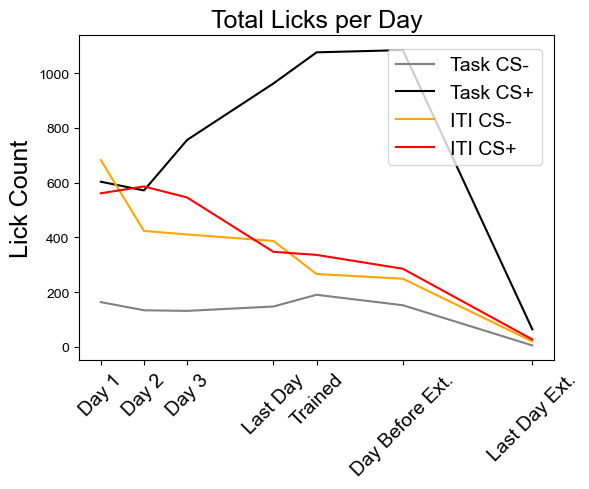

In [61]:
fig = plt.figure(figsize=(6,5))

title_fontsize=18
axis_fontsize=18
tick_fontsize=14

colors = ['gray', 'k', 'orange', 'r']
labels = ['Task CS-', 'Task CS+', 'ITI CS-', 'ITI CS+']
day_idxs = [0,1,2,3,4,5,7]

avg_lick_count = np.nanmean(total_licks_perday, axis=1)

xticks_ = [1,2,3,5,6,8,11]
_type = 0
for i in [0,1]: # task/iti index
    for j in [0,1]: # cs-/+ index
        plt.plot(xticks_, avg_lick_count[day_idxs,i,j], color=colors[_type], label=labels[_type])
        _type += 1

# plt.ylim([0,2])
# plt.yticks([0,2], fontsize=tick_fontsize)
plt.xticks(xticks_, ['Day 1','Day 2','Day 3','Last Day','Trained','Day Before Ext.','Last Day Ext.'], rotation=45, fontsize=tick_fontsize)
plt.ylabel("Lick Count", fontsize=axis_fontsize)
plt.title("Total Licks per Day", fontsize=title_fontsize)
plt.legend(loc=[0.65,0.6], fontsize=tick_fontsize)
plt.tight_layout()
plt.show()
# plt.savefig(replay_figure_folder+"Day1_vs_Otherdays_plot_pearsonr.svg", format="svg", dpi=150)
plt.close(fig)

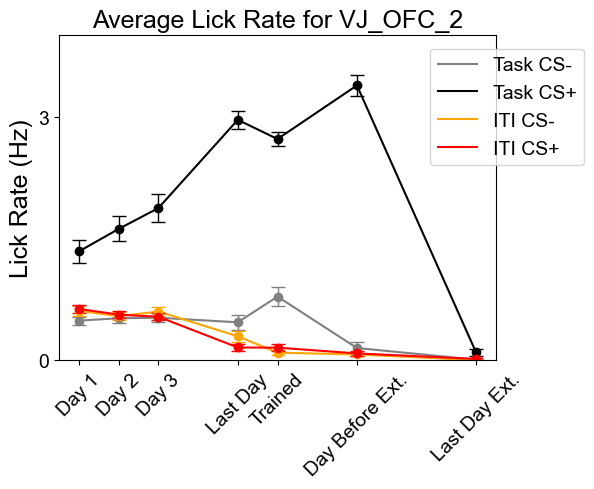

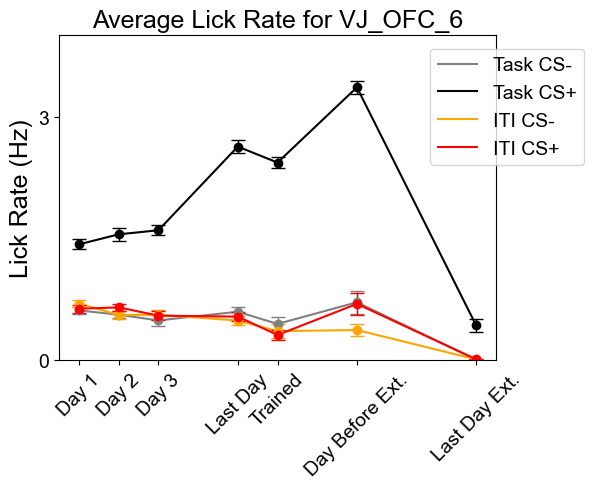

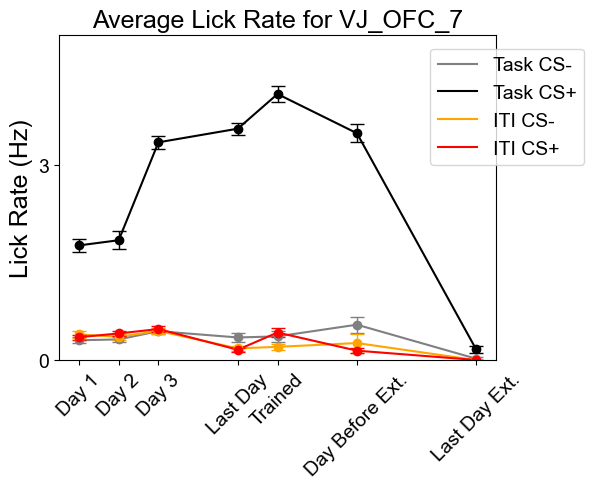

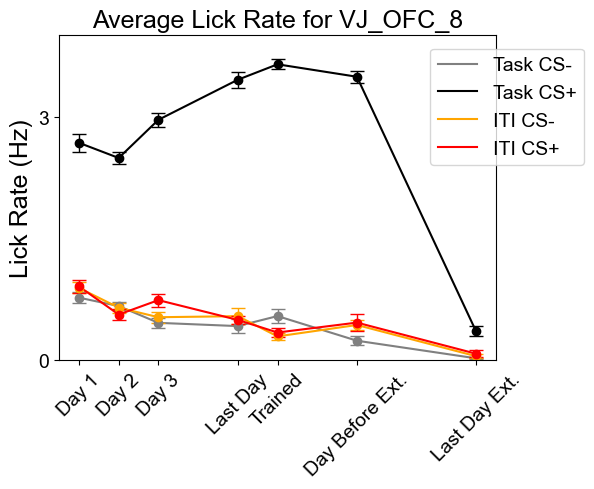

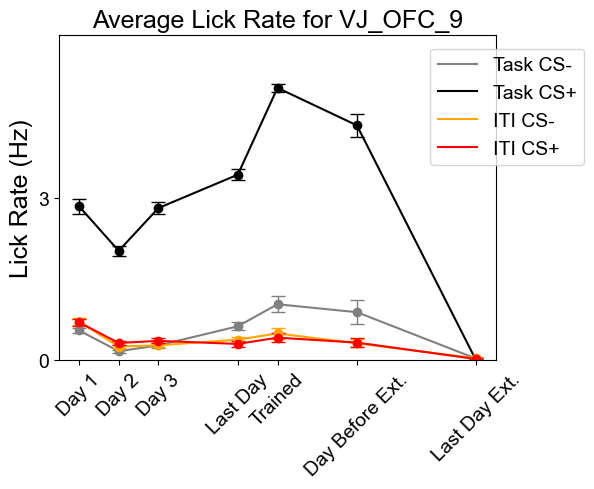

In [62]:
for ia, aid in enumerate(animal_id):
    fig = plt.figure(figsize=(6,5))
    
    title_fontsize=18
    axis_fontsize=18
    tick_fontsize=14
    
    colors = ['gray', 'k', 'orange', 'r']
    labels = ['Task CS-', 'Task CS+', 'ITI CS-', 'ITI CS+']
    day_idxs = [0,1,2,3,4,5,7]
    
    
    xticks_ = [1,2,3,5,6,8,11]
    _type = 0
    for i in [0,1]: # task/iti index
        for j in [0,1]: # cs-/+ index
            plt.errorbar(xticks_, lickrates[day_idxs,ia,i,j,0], yerr=lickrates[day_idxs,ia,i,j,1], fmt='o', capsize=5, color=colors[_type], elinewidth=1)
            plt.plot(xticks_, lickrates[day_idxs,ia,i,j,0], color=colors[_type], label=labels[_type])
            _type += 1
    
    plt.ylim([0,np.ceil(np.max(lickrates[day_idxs,ia, ...]))])
    plt.yticks([0,3], fontsize=tick_fontsize)
    plt.xticks(xticks_, ['Day 1','Day 2','Day 3','Last Day','Trained','Day Before Ext.','Last Day Ext.'], rotation=45, fontsize=tick_fontsize)
    plt.ylabel("Lick Rate (Hz)", fontsize=axis_fontsize)
    plt.title("Average Lick Rate for "+aid, fontsize=title_fontsize)
    plt.legend(loc=[0.85,0.6], fontsize=tick_fontsize)
    plt.tight_layout()
    # plt.savefig(replay_figure_folder+"Day1_vs_Otherdays_plot_pearsonr.svg", format="svg", dpi=150)
    plt.show()
    plt.close(fig)

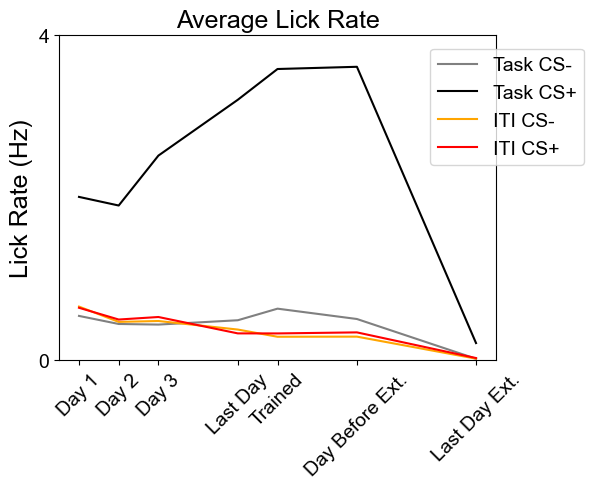

In [63]:
fig = plt.figure(figsize=(6,5))

title_fontsize=18
axis_fontsize=18
tick_fontsize=14

colors = ['gray', 'k', 'orange', 'r']
labels = ['Task CS-', 'Task CS+', 'ITI CS-', 'ITI CS+']
day_idxs = [0,1,2,3,4,5,7]

avglickrate = np.nanmean(lickrates, axis=1)

xticks_ = [1,2,3,5,6,8,11]
_type = 0
for i in [0,1]: # task/iti index
    for j in [0,1]: # cs-/+ index
        plt.plot(xticks_, avglickrate[day_idxs,i,j,0], color=colors[_type], label=labels[_type])
        _type += 1

plt.ylim([0,4])
plt.yticks([0,4], fontsize=tick_fontsize)
plt.xticks(xticks_, ['Day 1','Day 2','Day 3','Last Day','Trained','Day Before Ext.','Last Day Ext.'], rotation=45, fontsize=tick_fontsize)
plt.ylabel("Lick Rate (Hz)", fontsize=axis_fontsize)
plt.title("Average Lick Rate", fontsize=title_fontsize)
plt.legend(loc=[0.85,0.6], fontsize=tick_fontsize)
plt.tight_layout()
plt.show()
# plt.savefig(replay_figure_folder+"Day1_vs_Otherdays_plot_pearsonr.svg", format="svg", dpi=150)
plt.close(fig)

# Fixing Sequential Activation analysis (all days)
- editing all task and iti sequence analysis code for simplicity and reproducibility
- there was an issue separating iti's for trial types that was fixed in the "behavior" section above. implementing that fix below:
- also ITI and Task periods were overlapping before - will use 0-9000 for task, and 10000 beyond for ITI

### Figure Folders

In [64]:
base_figure_folder = "/Users/lukepemberton/Desktop/UCSF/Ensemble/ensemble/"

replay_figure_folder = base_figure_folder + "replay_figure/"
longitudinal_figure_folder = base_figure_folder + "longitudinal_figure/"

In [65]:
# unique_pairclst = np.vstack([[iclst,jclst] for idxi, iclst in enumerate(clstlist) for idxj, jclst in enumerate(clstlist[idxi+1:])])
# print(unique_pairclst.T)

We've found there is a temporal ordering of clusters on Trained day that is persistent through Task period and ITI. Is that true on Day 1?

In [66]:
def xcorr(x, y, maxlags=10):    
    Nx = len(x)
    if Nx != len(y):
        raise ValueError('x and y must be equal length')

    c = np.correlate((x-np.nanmean(x))/np.nanstd(x, ddof=1), (y-np.nanmean(y))/np.nanstd(y, ddof=1), mode=2)/(Nx-1)

    if maxlags is None:
        maxlags = Nx - 1

    if maxlags >= Nx or maxlags < 1:
        raise ValueError('maxlags must be None or strictly positive < %d' % Nx)

    c = c[Nx - 1 - maxlags:Nx + maxlags]
       
    return c

### A brief explanation of the bootstrapping process with xcorr:

The general process for hierarchical bootstrap is to precompute samples of the desired statistic at the lowest level of the hierarchy, and then sample them from replacement. This is equivalent to first sampling with replacement and then computing your desired statistic, but precomputing samples is EXPONENTIALLY faster.

In hierarchical bootstrap, at each level of the hierarchy you specify some samples with replacement, and then you descend to the next level and repeat, until you get to the bottom level.

The hierarchy for cross correlation is:
1. cluster pair (iterating thru each one)
2. Sessions (which is equivalent to animals, if there is one session per animal. Not the case with trained day data)
3. Trials (or ITIs)

The bootstrapping procedure for cross correlation in detail following the hierarchy laid out:
1. For each cluster pair, pre-compute the per trial cross correlation in each session.
2. Following the hierarchy above, take N bootstrap samples of each cross correlation for each cluster pair using the precomputed statistics
3. Use bootstrap samples in subsequent analyses

In [67]:
# version for cross correlation

# These are extremely optimized functions for performing step 2 above. They've already been checked for correctness.

def _bootstrap_pair_rep_variableT(session_arrays, nboot, rng, chunk_size=128, use_float32=True):
    """
    session_arrays: list of arrays, each shape (T_s, L) for one session (trials x lags)
    Returns: (nboot, L) bootstrap means for one (rep, pair), sampling trials
             within sessions and sessions themselves, both with replacement.
    """
    if len(session_arrays) == 0:
        raise ValueError("No sessions provided for this pair/rep.")

    # Validate consistent L
    Ls = [arr.shape[-1] for arr in session_arrays]
    L = Ls[0]
    if any(l != L for l in Ls):
        raise ValueError(f"Inconsistent L across sessions: {Ls}")

    # Optional downcast for speed
    if use_float32:
        session_arrays = [arr.astype(np.float32, copy=False) for arr in session_arrays]

    S = len(session_arrays)
    out = np.empty((nboot, L), dtype=session_arrays[0].dtype)

    done = 0
    while done < nboot:
        b = min(chunk_size, nboot - done)

        # Per-session trial resampling -> per-session means, all boots
        # session_means: (b, S, L)
        session_means = np.empty((b, S, L), dtype=session_arrays[0].dtype)

        for s, arr in enumerate(session_arrays):
            T_s = arr.shape[0]
            if T_s <= 0:
                # If a session has 0 trials, mark as NaN so nanmean over sessions ignores it
                session_means[:, s, :] = np.nan
                continue

            trial_idx = rng.integers(0, T_s, size=(b, T_s))       # (b, T_s)
            vals = arr[trial_idx, :]                               # (b, T_s, L)
            with np.errstate(all='ignore'):
                session_means[:, s, :] = np.nanmean(vals, axis=1)  # (b, L)

        # Now sample sessions with replacement per bootstrap (like your original)
        sess_idx = rng.integers(0, S, size=(b, S))                 # (b, S)
        b_idx = np.arange(b)[:, None]
        selected = session_means[b_idx, sess_idx, :]               # (b, S, L)
        with np.errstate(all='ignore'):
            boot_means_chunk = np.nanmean(selected, axis=1)        # (b, L)

        out[done:done + b] = boot_means_chunk
        done += b

    return out


def faster_bootstrap(nboot, pairclst, sessions_per_pair, xcorrmats_per_session,
                     num_reps, lagframe, seed=0, chunk_size=128, use_float32=True, verbose=True):
    """
    Vectorized bootstrap with variable trials per session.
    Expects xcorrmats_per_session[s][rep, ipair, :, :] -> (T_s, L)
    """
    rng = np.random.default_rng(seed)
    npair = len(pairclst)
    L = 2 * lagframe + 1
    dtype = np.float32 if use_float32 else np.float64
    bootstats_xcorr = np.zeros((nboot, npair, L), dtype=dtype)

    start_all = time_counter.time()
    for ipair, (iclst, jclst) in enumerate(pairclst):
        if verbose:
            print(f"on cluster pair: {iclst}  {jclst}")

        accum = np.zeros((nboot, L), dtype=dtype)

        counted_reps = 0
        for rep in range(num_reps):
            sessions_in_pair = sessions_per_pair[rep][(iclst, jclst)]
            if sessions_in_pair == []: print("skipped sessions_in_pair is empty for ", iclst, ", ", jclst, " on rep ", rep) continue # raise ValueError("sessions_in_pair is empty for ", iclst, ", ", jclst, " on rep ", rep)

            # Build list of (T_s, L) arrays without stacking (supports variable T_s)
            session_arrays = []
            for s in sessions_in_pair:
                arr = xcorrmats_per_session[s][rep, ipair, :, :]   # (T_s, L)
                if arr.shape[-1] != L:
                    raise ValueError(
                        f"L mismatch: session {s} has L={arr.shape[-1]} but expected {L}"
                    )
                session_arrays.append(arr)

            boots = _bootstrap_pair_rep_variableT(
                session_arrays, nboot, rng, chunk_size=chunk_size, use_float32=use_float32
            )
            accum += boots
            counted_reps += 1

        bootstats_xcorr[:, ipair, :] = accum / float(counted_reps)

        if verbose:
            elapsed = time_counter.time() - start_all
            print(f"time elapsed on ipair {ipair}: {elapsed:.2f}s")

    return bootstats_xcorr


## Setting data up
- using Huijeong's alignsignal2event function for this one as well as ITI

In [68]:
def alignsignal2event(signalframe,signal,eventtime,window,framesize=200):
    # framesize = int(np.round(np.median(np.diff(signalframe))))
    eventframe = [int(i) for i in np.squeeze(framenumberforevent(eventtime,signalframe))]
    nevent = len(eventframe)
    
    if len(window)==2:
        windowinframe = [int(i/framesize) for i in window]
        time = range(window[0],window[1],framesize)
        ntime = len(time)
        alignedsignal = np.nan*np.zeros([nevent,signal.shape[0],ntime])
    else:
        windowinframe = np.squeeze([[int(i/framesize),int(j/framesize)] for (i,j) in window])
        alignedsignal = [None]*nevent
        

    for ie in range(nevent):
        if len(window)==2:
            if eventframe[ie]+windowinframe[0]<0:
                alignedsignal[ie,:,ntime-eventframe[ie]-windowinframe[1]:] = signal[:,0:eventframe[ie]+windowinframe[1]]
            elif eventframe[ie]+windowinframe[1]>len(signalframe):
                alignedsignal[ie,:,:len(signalframe)-(eventframe[ie]+windowinframe[0])] = signal[:,eventframe[ie]+windowinframe[0]:]
            else:
                # print("alignedsignal.shape: ", alignedsignal.shape)
                # print("signal.shape: ", signal.shape)
                # print("signal[...].shape: ", signal[:,eventframe[ie]+windowinframe[0]:eventframe[ie]+windowinframe[1]].shape)
                # print("eventframe: ", eventframe[ie])
                # print("windowinframe: ", windowinframe)
                # print("framesize: ", framesize)
                # print("len signalframe", len(signalframe))
                alignedsignal[ie,:,:] = signal[:,eventframe[ie]+windowinframe[0]:eventframe[ie]+windowinframe[1]]
        
        else:
            time = range(window[ie,0],window[ie,1],framesize)
            ntime = len(time)
            alignedsignal[ie] = np.nan*np.zeros([signal.shape[0],ntime])
            if eventframe[ie]+windowinframe[ie,0]<0:
                alignedsignal[ie][:,ntime-eventframe[ie]-windowinframe[ie,1]:] = signal[:,0:eventframe[ie]+windowinframe[ie,1]]
            elif eventframe[ie]+windowinframe[ie,1]>len(signalframe):
                alignedsignal[ie][:,:len(signalframe)-(eventframe[ie]+windowinframe[ie,0])] = signal[:,eventframe[ie]+windowinframe[ie,0]:]
            else:
                alignedsignal[ie] = signal[:,eventframe[ie]+windowinframe[ie,0]:eventframe[ie]+windowinframe[ie,1]]
        
    return time, alignedsignal

In [70]:
snrthreshold = 0.75
inclst_thres = 4
num_reps = 100

# clstlist = np.unique(cluster_results[trained_folder[0]])[1:]
clstlist = [0,1,2,3,4,5,6]
print(clstlist)
nclst = len(clstlist)
nsession = len(session_folder[animal_id[0]])
print(nsession)
df_day_indxs = [0,1,2,3,4,5,6,7]

cswindow = [0,10000]

nclst = len(clstlist)

lagtime = 3000
framesize = 200
lagframe = int(lagtime/framesize)
print(lagframe)
lag = range(-lagtime,lagtime+10,framesize)

npair = int(nclst*(nclst-1)/2+nclst)
pairclst = np.vstack([[iclst,jclst] for idxi, iclst in enumerate(clstlist) for idxj, jclst in enumerate(clstlist[idxi:])])

[0, 1, 2, 3, 4, 5, 6]
8
15


In [71]:
for iss in range(0, nsession):  
    for ia, aid in enumerate(animal_id):
        fdata = frame[aid][df_day_indxs[iss]]
        cur_framesize = int(np.round(np.median(np.diff(fdata))))
        print(cur_framesize)

200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
199
199
199
200
200
199
199
200
200
200


### Task - per trial type
- You can just concatenate across trial types after the fact

In [72]:
sessions_per_pair_task = {} # use this to determine which animals to sample for a bootstrap sample
xcorrmat_per_session_ = {} # use this to fetch pairwise corrs in combination with clusteridx

for iss in range(0, nsession):  
    start = time_counter.time()
    
    sessions_per_pair_task[iss] = {}
    xcorrmat_per_session_[iss] = {}
    
    for rep in range(num_reps):
        sessions_per_pair_task[iss][rep] = {}
        for ipair,(iclst,jclst) in enumerate(pairclst):
            sessions_per_pair_task[iss][rep][(iclst,jclst)] = []
    
    print(sessions_per_pair_task[iss][0].keys())
    
    for ia, aid in enumerate(animal_id):
        xcorrmat_per_session_[iss][aid] = {}

        ## right here is where you align your cell ids with your cluster labels
        df = pandas.DataFrame.from_dict(cell_log[aid])
        
        # add the clustering labels to the trained day in the cell log reference table so its consistent across days
        trained_mask = df[sessionnames[aid][4]] > 0 # this is a particular day 
        dftrue = df[sessionnames[aid].to_list()]>0
        inregistered = list(dftrue.sum(axis=1)==dftrue.shape[1])
        df['in_analysis'] = inregistered
    
        print("trained day: ", trained_folder[ia])
        for rep in range(num_reps):
            df['cluster_labels_'+str(rep)] = np.nan
            df.loc[trained_mask, 'cluster_labels_'+str(rep)] = cluster_results[trained_folder[ia]][rep, :].squeeze() # set up a new row in pandas dataframe and insert your cluster labels
        
        print("on animal ", aid, ", session ", session_folder[aid][iss])
        
        ndata = neuraldata[aid][df_day_indxs[iss]]
        bdata = behdata[aid][df_day_indxs[iss]]
        fdata = frame[aid][df_day_indxs[iss]]
        
        csplustime = np.setdiff1d(bdata['cues'], bdata['cuesminus'])
        csminustime = np.squeeze(np.array(bdata['cuesminus']))

        if flipcsminusflag[aid][iss]: 
            csvars = [csminustime, csplustime]
        else: 
            csvars = [csplustime, csminustime]
        for ttype_idx, cstime in enumerate(csvars): # CS- is 0 index, CS+ is 1 index
            print("ndata shape: ", ndata.shape)
            [time,tasksignal] = alignsignal2event(fdata,ndata,cstime,cswindow)

            xcorrmat_per_session_[iss][aid][ttype_idx] = np.zeros((num_reps,npair,tasksignal.shape[0],2*lagframe + 1))
        
            snr = np.std(tasksignal, axis=1)                 # SNR for each row
            print("snr shape:", snr.shape)
            k = int(np.ceil(len(snr) * snrthreshold)) # how many rows make the cut
            snr_idxs = np.argsort(-snr)[:k]
        
            print(df.columns.values[df_day_indxs[iss]])
            session_mask = df[df.columns.values[df_day_indxs[iss]]] > 0
            print(np.sum(session_mask))
        
            for rep in range(num_reps):
                ipair = 0
                for idxi, iclst in enumerate(clstlist):
                    iflag = (
                        df.loc[session_mask, 'in_analysis'] &
                        (df.loc[session_mask, 'cluster_labels_'+str(rep)] == iclst)
                    ) # use aligned cluster labels to analyze consistent cells across sessions
                    iclst_indxs = np.intersect1d(np.squeeze(np.where(iflag)), snr_idxs)
                    niniclst = len(iclst_indxs)
        
                    for jclst in clstlist[idxi:]:
                        jflag = (
                            df.loc[session_mask, 'in_analysis'] &
                            (df.loc[session_mask, 'cluster_labels_'+str(rep)] == jclst)
                        ) # use aligned cluster labels to analyze consistent cells across sessions
                        jclst_indxs = np.intersect1d(np.squeeze(np.where(jflag)), snr_idxs)
                        ninjclst = len(jclst_indxs)
        
                        if (niniclst >= inclst_thres) and (ninjclst >= inclst_thres):
                            sessions_per_pair_task[iss][rep][(iclst,jclst)].append(aid)
                            xcorrmat_pertrial = np.vstack([xcorr(tasksignal[trial,iclst_indxs,:].mean(0), 
                                                              tasksignal[trial,jclst_indxs,:].mean(0), maxlags=lagframe) 
                                                        for trial in range(tasksignal.shape[0])])
                            xcorrmat_per_session_[iss][aid][ttype_idx][rep,ipair,:,:] = xcorrmat_pertrial
                        
                        ipair += 1


    stop = time_counter.time()
    print("\ntime elapsed: ", stop - start, "\n")

dict_keys([(0, 0), (0, 1), (0, 2), (0, 3), (0, 4), (0, 5), (0, 6), (1, 1), (1, 2), (1, 3), (1, 4), (1, 5), (1, 6), (2, 2), (2, 3), (2, 4), (2, 5), (2, 6), (3, 3), (3, 4), (3, 5), (3, 6), (4, 4), (4, 5), (4, 6), (5, 5), (5, 6), (6, 6)])
trained day:  VJ_OFC_2/D14_trained
on animal  VJ_OFC_2 , session  D4_first day of learning
ndata shape:  (172, 17953)
snr shape: (50, 50)
D1_first day of learning
172


/var/folders/sn/65fjtq095v12cns52v83pc0m0000gn/T/ipykernel_53057/1376689021.py:30: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['cluster_labels_'+str(rep)] = np.nan
/var/folders/sn/65fjtq095v12cns52v83pc0m0000gn/T/ipykernel_53057/1376689021.py:30: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['cluster_labels_'+str(rep)] = np.nan


ndata shape:  (172, 17953)
snr shape: (50, 50)
D1_first day of learning
172
trained day:  VJ_OFC_6/D9_trained
on animal  VJ_OFC_6 , session  D4_first day of learning
ndata shape:  (297, 14789)
snr shape: (50, 50)
D1_first day of learning
297


/var/folders/sn/65fjtq095v12cns52v83pc0m0000gn/T/ipykernel_53057/1376689021.py:30: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['cluster_labels_'+str(rep)] = np.nan
/var/folders/sn/65fjtq095v12cns52v83pc0m0000gn/T/ipykernel_53057/1376689021.py:30: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['cluster_labels_'+str(rep)] = np.nan


ndata shape:  (297, 14789)
snr shape: (50, 50)
D1_first day of learning
297
trained day:  VJ_OFC_7/D9_trained
on animal  VJ_OFC_7 , session  D4_first day of learning
ndata shape:  (410, 15412)
snr shape: (50, 50)
D1_first day of learning
410


...

ndata shape:  (402, 18905)
snr shape: (50, 50)
D25_last day of extinction
402
trained day:  VJ_OFC_8/D15_trained
on animal  VJ_OFC_8 , session  D27_last day of extinction
ndata shape:  (393, 17921)
snr shape: (50, 50)
D24_last day of extinction
393


/var/folders/sn/65fjtq095v12cns52v83pc0m0000gn/T/ipykernel_53057/1376689021.py:30: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['cluster_labels_'+str(rep)] = np.nan
/var/folders/sn/65fjtq095v12cns52v83pc0m0000gn/T/ipykernel_53057/1376689021.py:30: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['cluster_labels_'+str(rep)] = np.nan
/var/folders/sn/65fjtq095v12cns52v83pc0m0000gn/T/ipykernel_53057/628987499.py:6: RuntimeWarning: invalid value encountered in divide
  c = np.correlate((x-np.nanmean(x))/np.nanstd(x, ddof=1), (y-n

ndata shape:  (393, 17921)
snr shape: (50, 50)
D24_last day of extinction
393
trained day:  VJ_OFC_9/D9_trained
on animal  VJ_OFC_9 , session  D26_last day of extinction
ndata shape:  (387, 16105)
snr shape: (50, 50)
D23_last day of extinction
387


/var/folders/sn/65fjtq095v12cns52v83pc0m0000gn/T/ipykernel_53057/1376689021.py:30: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['cluster_labels_'+str(rep)] = np.nan
/var/folders/sn/65fjtq095v12cns52v83pc0m0000gn/T/ipykernel_53057/1376689021.py:30: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['cluster_labels_'+str(rep)] = np.nan
/var/folders/sn/65fjtq095v12cns52v83pc0m0000gn/T/ipykernel_53057/628987499.py:6: RuntimeWarning: invalid value encountered in divide
  c = np.correlate((x-np.nanmean(x))/np.nanstd(x, ddof=1), (y-n

ndata shape:  (387, 16105)
snr shape: (50, 50)
D23_last day of extinction
387

time elapsed:  89.5362377166748 



In [73]:
samples_save_folder = "/Users/lukepemberton/Desktop/OFC_Backup/Task_samples/"
file_path = samples_save_folder + f"task_xcorr_samples_pertrialtype_corrected.pkl"
with open(file_path, "wb") as f:
    pickle.dump(xcorrmat_per_session_, f)

file_path = samples_save_folder + f"task_xcorr_sessions_per_pair_pertrialtype_corrected.pkl"
with open(file_path, "wb") as f:
    pickle.dump(sessions_per_pair_task, f)

### ITI
- You can just concatenate across trial types after the fact

In [74]:
# ITI

sessions_per_pair_iti = {} # use this to determine which animals to sample for a bootstrap sample
xcorriti_per_session_ = {} # use this to fetch pairwise corrs in combination with clusteridx

for iss in range(0, nsession):  
    start = time_counter.time()
    
    sessions_per_pair_iti[iss] = {}
    xcorriti_per_session_[iss] = {}
    
    for rep in range(num_reps):
        sessions_per_pair_iti[iss][rep] = {}
        for ipair,(iclst,jclst) in enumerate(pairclst):
            sessions_per_pair_iti[iss][rep][(iclst,jclst)] = []
    
    print(sessions_per_pair_iti[iss][0].keys())
    
    for ia, aid in enumerate(animal_id):
        xcorriti_per_session_[iss][aid] = {}
        
        df = pandas.DataFrame.from_dict(cell_log[aid])
        
        # add the clustering labels to the trained day in the cell log reference table so its consistent across days
        trained_mask = df[sessionnames[aid][4]] > 0
        dftrue = df[sessionnames[aid].to_list()]>0
        inregistered = list(dftrue.sum(axis=1)==dftrue.shape[1])
        df['in_analysis'] = inregistered
    
        print("trained day: ", trained_folder[ia])
        for rep in range(num_reps):
            df['cluster_labels_'+str(rep)] = np.nan
            df.loc[trained_mask, 'cluster_labels_'+str(rep)] = cluster_results[trained_folder[ia]][rep, :].squeeze()
        
        # nsession = len(ndata)
        print("on animal ", aid, ", session ", session_folder[aid][iss])
        
        ndata = neuraldata[aid][df_day_indxs[iss]]
        bdata = behdata[aid][df_day_indxs[iss]]
        fdata = frame[aid][df_day_indxs[iss]]

        allcuestime = bdata['cues']
        allvacuumtime = np.squeeze(allcuestime[:-1]+iti_starttime)
        alliti = allcuestime[1:,0]-allvacuumtime
        
        csplustime = np.setdiff1d(bdata['cues'], bdata['cuesminus'])
        csminustime = np.squeeze(np.array(bdata['cuesminus']))

        _itiplus_filter = np.isin((alliti + allvacuumtime), csplustime) # the iti plus windows 
        itiplus = alliti[_itiplus_filter]
        vacuumtime_csplus = allvacuumtime[_itiplus_filter]

        _itiminus_filter = np.isin((alliti + allvacuumtime), csminustime) # the iti minus windows 
        itiminus = alliti[_itiminus_filter]
        vacuumtime_csminus = allvacuumtime[_itiminus_filter]


        if flipcsminusflag[aid][iss]: 
            itivars = [(itiminus, vacuumtime_csminus), (itiplus, vacuumtime_csplus)]
        else: 
            itivars = [(itiplus, vacuumtime_csplus), (itiminus, vacuumtime_csminus)]
            
        for ttype_idx, (iti, vacuumtime) in enumerate(itivars): # CS- is 0 index, CS+ is 1 index
            print("ndata shape: ", ndata.shape)
            shortiti = iti<(lagframe+1)*framesize # if iti is too short such that you can't compute corr, exclude 
            
            window = np.vstack((np.squeeze(np.zeros([iti.shape[0],1])),iti)).T
            window = np.squeeze([[int(i), int(j)] for (i,j) in window])
            
            [time,itisignal] = alignsignal2event(fdata,ndata,vacuumtime[~shortiti],window[~shortiti,:])
            
            xcorriti_per_session_[iss][aid][ttype_idx] = np.zeros((num_reps,npair,len(itisignal),2*lagframe + 1))
        
            conc_iti = np.concatenate(itisignal, axis=1).T
            snr = np.std(conc_iti, axis=0)                 # SNR for each row
            print("snr shape:", snr.shape)
            k = int(np.ceil(len(snr) * snrthreshold)) # how many rows make the cut
            snr_idxs = np.argsort(-snr)[:k]
        
            print(df.columns.values[df_day_indxs[iss]])
            session_mask = df[df.columns.values[df_day_indxs[iss]]] > 0
            print(np.sum(session_mask))
        
            for rep in range(num_reps):
                ipair = 0
                for idxi, iclst in enumerate(clstlist):
                    iflag = (
                        df.loc[session_mask, 'in_analysis'] &
                        (df.loc[session_mask, 'cluster_labels_'+str(rep)] == iclst)
                    ) # use aligned cluster labels to analyze consistent cells across sessions
                    iclst_indxs = np.intersect1d(np.squeeze(np.where(iflag)), snr_idxs)
                    iclst_indxs = iclst_indxs[iclst_indxs < itisignal[0].shape[0]] # had to force this because the discrepancy
                    niniclst = len(iclst_indxs)
        
                    for jclst in clstlist[idxi:]:
                        jflag = (
                            df.loc[session_mask, 'in_analysis'] &
                            (df.loc[session_mask, 'cluster_labels_'+str(rep)] == jclst)
                        ) # use aligned cluster labels to analyze consistent cells across sessions
                        jclst_indxs = np.intersect1d(np.squeeze(np.where(jflag)), snr_idxs)
                        jclst_indxs = jclst_indxs[jclst_indxs < itisignal[0].shape[0]] # had to force this because the discrepancy
                        ninjclst = len(jclst_indxs)
        
                        if (niniclst >= inclst_thres) and (ninjclst >= inclst_thres):
                            sessions_per_pair_iti[iss][rep][(iclst,jclst)].append(aid)
                            xcorriti_pertrial = np.vstack([xcorr(signal[iclst_indxs,:].mean(0), 
                                                              signal[jclst_indxs,:].mean(0), maxlags=lagframe) 
                                                        for signal in itisignal])
                            xcorriti_per_session_[iss][aid][ttype_idx][rep,ipair,:,:] = xcorriti_pertrial
                        
                        ipair += 1

    stop = time_counter.time()
    print("\ntime elapsed: ", stop - start, "\n")

dict_keys([(0, 0), (0, 1), (0, 2), (0, 3), (0, 4), (0, 5), (0, 6), (1, 1), (1, 2), (1, 3), (1, 4), (1, 5), (1, 6), (2, 2), (2, 3), (2, 4), (2, 5), (2, 6), (3, 3), (3, 4), (3, 5), (3, 6), (4, 4), (4, 5), (4, 6), (5, 5), (5, 6), (6, 6)])
trained day:  VJ_OFC_2/D14_trained
on animal  VJ_OFC_2 , session  D4_first day of learning
ndata shape:  (172, 17953)
snr shape: (172,)
D1_first day of learning
172


/var/folders/sn/65fjtq095v12cns52v83pc0m0000gn/T/ipykernel_53057/4274230614.py:32: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['cluster_labels_'+str(rep)] = np.nan
/var/folders/sn/65fjtq095v12cns52v83pc0m0000gn/T/ipykernel_53057/4274230614.py:32: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['cluster_labels_'+str(rep)] = np.nan


ndata shape:  (172, 17953)
snr shape: (172,)
D1_first day of learning
172


/var/folders/sn/65fjtq095v12cns52v83pc0m0000gn/T/ipykernel_53057/628987499.py:6: RuntimeWarning: invalid value encountered in divide
  c = np.correlate((x-np.nanmean(x))/np.nanstd(x, ddof=1), (y-np.nanmean(y))/np.nanstd(y, ddof=1), mode=2)/(Nx-1)


trained day:  VJ_OFC_6/D9_trained
on animal  VJ_OFC_6 , session  D4_first day of learning
ndata shape:  (297, 14789)
snr shape: (297,)
D1_first day of learning
297


...

ndata shape:  (402, 18905)
snr shape: (402,)
D25_last day of extinction
402
trained day:  VJ_OFC_8/D15_trained
on animal  VJ_OFC_8 , session  D27_last day of extinction
ndata shape:  (393, 17921)
snr shape: (393,)
D24_last day of extinction
393


/var/folders/sn/65fjtq095v12cns52v83pc0m0000gn/T/ipykernel_53057/4274230614.py:32: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['cluster_labels_'+str(rep)] = np.nan
/var/folders/sn/65fjtq095v12cns52v83pc0m0000gn/T/ipykernel_53057/4274230614.py:32: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['cluster_labels_'+str(rep)] = np.nan
/var/folders/sn/65fjtq095v12cns52v83pc0m0000gn/T/ipykernel_53057/628987499.py:6: RuntimeWarning: invalid value encountered in divide
  c = np.correlate((x-np.nanmean(x))/np.nanstd(x, ddof=1), (y-n

ndata shape:  (393, 17921)
snr shape: (393,)
D24_last day of extinction
393
trained day:  VJ_OFC_9/D9_trained
on animal  VJ_OFC_9 , session  D26_last day of extinction
ndata shape:  (387, 16105)
snr shape: (387,)
D23_last day of extinction
387


/var/folders/sn/65fjtq095v12cns52v83pc0m0000gn/T/ipykernel_53057/4274230614.py:32: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['cluster_labels_'+str(rep)] = np.nan
/var/folders/sn/65fjtq095v12cns52v83pc0m0000gn/T/ipykernel_53057/4274230614.py:32: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['cluster_labels_'+str(rep)] = np.nan


ndata shape:  (387, 16105)
snr shape: (387,)
D23_last day of extinction
387

time elapsed:  119.75233387947083 



In [75]:
samples_save_folder = "/Users/lukepemberton/Desktop/OFC_Backup/ITI_samples/"
file_path = samples_save_folder + f"iti_xcorr_samples_pertrialtype_corrected.pkl"
with open(file_path, "wb") as f:
    pickle.dump(xcorriti_per_session_, f)

file_path = samples_save_folder + f"iti_xcorr_sessions_per_pair_pertrialtype_corrected.pkl"
with open(file_path, "wb") as f:
    pickle.dump(sessions_per_pair_iti, f)

In [76]:
xcorriti_per_session_[0]['VJ_OFC_2']

{0: array([[[[ 1.32488433e-01,  1.02003540e-01,  1.12124551e-01, ...,
            1.12124551e-01,  1.02003540e-01,  1.32488433e-01],
          [-1.82565564e-01, -2.10243350e-01, -2.15397577e-01, ...,
           -2.15397577e-01, -2.10243350e-01, -1.82565564e-01],
          [-1.08825771e-01, -1.84922369e-01, -1.84306296e-01, ...,
           -1.84306296e-01, -1.84922369e-01, -1.08825771e-01],
          ...,
          [ 1.43585203e-02,  4.29688779e-03, -1.46359505e-02, ...,
           -1.46359505e-02,  4.29688779e-03,  1.43585203e-02],
          [ 6.92164656e-02,  1.55226133e-01,  1.06044150e-01, ...,
            1.06044150e-01,  1.55226133e-01,  6.92164656e-02],
          [-5.93069989e-02, -5.97578201e-02,  1.66860149e-02, ...,
            1.66860149e-02, -5.97578201e-02, -5.93069989e-02]],
 
         [[ 1.29968606e-01,  1.39316254e-01,  1.89040565e-01, ...,
            2.13433602e-01,  1.41784666e-01,  9.09038825e-02],
          [-1.65825102e-01, -2.35635285e-01, -2.17056965e-01, ...,
  

## Bootstrap

# Reward sequence analysis

only during task of course

In [86]:
# TASK
# rewriting the noise correlation code below using flourescence instead of inferred spikes
# signal_type = '_medianscaling' #Fluorescence median scaling
signal_type = '_none'
# signal_type = ''
variable_within_session = '_inferredspikes' # '' for flourescence, '_inferredspikes' o.w.
snrthreshold = 0.75
inclst_thres = 4
num_reps = 100

# clstlist = np.unique(cluster_results[trained_folder[0]])[1:]
clstlist = [0,1,2,3,4,5,6]
print(clstlist)
nclst = len(clstlist)
nsession = len(session_folder[animal_id[0]])
print(nsession)
df_day_indxs = [0,1,2,3,4,5,6,7,8]

cswindow = [0,6000]

nclst = len(clstlist)
framesize = 200
lagtime = 2000
lagframe = int(lagtime/framesize)
lag = range(-lagtime,lagtime+10,framesize)

npair = int(nclst*(nclst-1)/2+nclst)
pairclst = np.vstack([[iclst,jclst] for idxi, iclst in enumerate(clstlist) for idxj, jclst in enumerate(clstlist[idxi:])])

print('Alignedtotrial%s%s.pickle'%(signal_type, variable_within_session))
print(session_folder[animal_id[0]])
print(session_folder[animal_id[1]])

[0, 1, 2, 3, 4, 5, 6]
9
Alignedtotrial_none_inferredspikes.pickle
['D4_first day of learning', 'D5_second day of learning', 'D6', 'D7', 'D13_last day of learning', 'D14_trained', 'D21_day before extinction', 'D24_first day of extinction', 'D25_last day of extinction']
['D4_first day of learning', 'D5_second day of learning', 'D6', 'D7', 'D8_last day of learning', 'D9_trained', 'D29_day before extinction', 'D30_first day of extinction', 'D31_last day of extinction']


In [234]:
# reward sequence data 
samples_save_folder = "/Users/lukepemberton/Desktop/OFC_Backup/Task_samples/"

assert(pairclst.shape[0] == npair)
print(pairclst.shape)

for iss in [0,1,2,3,4,5,6,7,8]:
    sessions_per_pair = {} # use this to determine which animals to sample for a bootstrap sample
    xcorrmats_per_session_pertrialtype = {} # use this to fetch pairwise corrs in combination with clusteridx
    
    for rep in range(num_reps): # to make it easy to sample
        sessions_per_pair[rep] = {}
        for ipair,(iclst,jclst) in enumerate(pairclst):
            sessions_per_pair[rep][(iclst,jclst)] = []
    
    print(sessions_per_pair[0].keys())
    
    xcorrmats_per_session_pertrialtype[0] = {} # 0: minus ITIs, 1: plus ITIs (I THINK, need to check) 
    xcorrmats_per_session_pertrialtype[1] = {}
    
    
    for ia, aid in enumerate(animal_id):    
        df = pandas.DataFrame.from_dict(cell_log[aid])
        
        # add the clustering labels to the trained day in the cell log reference table so its consistent across days
        trained_mask = df[sessionnames[aid][5]] > 0
        dftrue = df[sessionnames[aid].to_list()]>0
        inregistered = list(dftrue.sum(axis=1)==dftrue.shape[1])
        df['in_analysis'] = inregistered
    
        for rep in range(num_reps):
            df['cluster_labels_'+str(rep)] = np.nan
            df.loc[trained_mask, 'cluster_labels_'+str(rep)] = cluster_results[trained_folder[ia]][rep, :].squeeze()


        if aid == "VJ_OFC_2" and session_folder[aid][iss] == "D21_day before extinction":
            basepath = desktopdir + aid + '/'
            cursessionpath = basepath + "D21_day before extinction"
            print("current session path is ", cursessionpath)
            
            with open(cursessionpath + '/' + ('Alignedtotrial%s%s.pickle'%(signal_type, variable_within_session)), 'rb') as f:
                trialdat = pickle.load(f, encoding="latin1", fix_imports=True)
        else:
            basepath = base_dir + aid + '/'
            cursessionpath = basepath + session_folder[aid][iss]
            print("current session path is ", cursessionpath)
        
            with open(cursessionpath + '/' + ('Alignedtotrial%s%s.pickle'%(signal_type, variable_within_session)), 'rb') as f:
                trialdat = pickle.load(f, encoding="latin1", fix_imports=True)
        
    
        plustrials = remove_nan_trials(trialdat['plus'])[:,30:,:] # get rid of nan trials AND filter for post reward delivery period
        print(plustrials.shape)
        minustrials = remove_nan_trials(trialdat['minus'])[:,30:,:]
        print(minustrials.shape)
    
        # csnoise = np.concatenate([plustrials, minustrials], axis=0) # stack and concatenate plus and minus trials
        for trialidx, trials in enumerate([minustrials, plustrials]):
    
            print("trials shape: ", trials.shape)
            Ntrials, _, Ncells = trials.shape
            
            xcorrmats_per_session_pertrialtype[trialidx][aid + '/' + session_folder[aid][iss]] = np.full((num_reps,npair,Ntrials,2*lagframe + 1), np.nan)
    
            snr = np.std(trials, axis=0)                 # SNR for each row
            print("snr shape:", snr.shape)
            k = int(np.ceil(len(snr) * snrthreshold)) # how many rows make the cut
            snr_idxs = np.argsort(-snr)[:k]
    
            print(df.columns.values[df_day_indxs[iss]])
            session_mask = df[df.columns.values[df_day_indxs[iss]]] > 0
            assert(Ncells == np.sum(session_mask))
        
            for rep in range(num_reps):
                ipair = 0
                for idxi, iclst in enumerate(clstlist):
                    iflag = (
                        df.loc[session_mask, 'in_analysis'] &
                        (df.loc[session_mask, 'cluster_labels_'+str(rep)] == iclst)
                    ) # use aligned cluster labels to analyze consistent cells across sessions
                    iclst_indxs = np.intersect1d(np.squeeze(np.where(iflag)), snr_idxs)
                    niniclst = len(iclst_indxs)
        
                    for jclst in clstlist[idxi:]:
                        jflag = (
                            df.loc[session_mask, 'in_analysis'] &
                            (df.loc[session_mask, 'cluster_labels_'+str(rep)] == jclst)
                        ) # use aligned cluster labels to analyze consistent cells across sessions
                        jclst_indxs = np.intersect1d(np.squeeze(np.where(jflag)), snr_idxs)
                        ninjclst = len(jclst_indxs)
        
                        if (niniclst >= inclst_thres) and (ninjclst >= inclst_thres):
                            # add the session that this cluster pair is in to the ones to get sampled from - this cluster pair has sufficient number of neurons in both clusters
                            sessions_per_pair[rep][(iclst,jclst)].append(aid + '/' + session_folder[aid][iss])
    
                            # precompute cross correlation HERE for the given session, rep, and cluster pair
                            # compute cross correlation for each trial and save so we can sample trials
                            # for each cluster pair, we compute the cross correlation for each trial after averaging the trace across neurons (the 'cluster average')
                            xcorr_pertrial = np.vstack([xcorr(trials[trial,:,iclst_indxs].mean(0).squeeze(), # the mean axis IS CORRECT, for whatever reason the csnoise indexing flips them
                                                              trials[trial,:,jclst_indxs].mean(0).squeeze(), maxlags=lagframe) 
                                                        for trial in range(trials.shape[0])])
                            xcorrmats_per_session_pertrialtype[trialidx][aid + '/' + session_folder[aid][iss]][rep,ipair,:,:] = xcorr_pertrial
                        
                        ipair += 1
    
    
    print()
    print("Moving to next day")
    print()
    
    file_path = samples_save_folder + f"day{iss}_task_xcorr_samples_pertrialtype_reward.pkl"
    with open(file_path, "wb") as f:
        pickle.dump(xcorrmats_per_session_pertrialtype, f)
    
    file_path = samples_save_folder + f"day{iss}_task_session_samples_pertrialtype_reward.pkl"
    with open(file_path, "wb") as f:
        pickle.dump(sessions_per_pair, f)       

(28, 2)
dict_keys([(np.float64(0.0), np.float64(0.0)), (np.float64(0.0), np.float64(1.0)), (np.float64(0.0), np.float64(2.0)), (np.float64(0.0), np.float64(3.0)), (np.float64(0.0), np.float64(4.0)), (np.float64(0.0), np.float64(5.0)), (np.float64(0.0), np.float64(6.0)), (np.float64(1.0), np.float64(1.0)), (np.float64(1.0), np.float64(2.0)), (np.float64(1.0), np.float64(3.0)), (np.float64(1.0), np.float64(4.0)), (np.float64(1.0), np.float64(5.0)), (np.float64(1.0), np.float64(6.0)), (np.float64(2.0), np.float64(2.0)), (np.float64(2.0), np.float64(3.0)), (np.float64(2.0), np.float64(4.0)), (np.float64(2.0), np.float64(5.0)), (np.float64(2.0), np.float64(6.0)), (np.float64(3.0), np.float64(3.0)), (np.float64(3.0), np.float64(4.0)), (np.float64(3.0), np.float64(5.0)), (np.float64(3.0), np.float64(6.0)), (np.float64(4.0), np.float64(4.0)), (np.float64(4.0), np.float64(5.0)), (np.float64(4.0), np.float64(6.0)), (np.float64(5.0), np.float64(5.0)), (np.float64(5.0), np.float64(6.0)), (np.float

/var/folders/sn/65fjtq095v12cns52v83pc0m0000gn/T/ipykernel_18918/3634918649.py:31: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['cluster_labels_'+str(rep)] = np.nan
/var/folders/sn/65fjtq095v12cns52v83pc0m0000gn/T/ipykernel_18918/3634918649.py:31: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['cluster_labels_'+str(rep)] = np.nan


(41, 70, 172)
(37, 70, 172)
trials shape:  (37, 70, 172)
snr shape: (70, 172)
D1_first day of learning
trials shape:  (41, 70, 172)
snr shape: (70, 172)
D1_first day of learning


/var/folders/sn/65fjtq095v12cns52v83pc0m0000gn/T/ipykernel_18918/3634918649.py:31: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['cluster_labels_'+str(rep)] = np.nan
/var/folders/sn/65fjtq095v12cns52v83pc0m0000gn/T/ipykernel_18918/3634918649.py:31: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['cluster_labels_'+str(rep)] = np.nan


current session path is  /Volumes/Vijay4_backup/2p data/VJ_OFC_6/D4_first day of learning
(37, 70, 297)
(30, 70, 297)
trials shape:  (30, 70, 297)
snr shape: (70, 297)
D1_first day of learning
trials shape:  (37, 70, 297)
snr shape: (70, 297)
D1_first day of learning


...

current session path is  /Volumes/Vijay4_backup/2p data/VJ_OFC_7/D28_last day of extinction
(40, 70, 402)
(36, 70, 402)
trials shape:  (36, 70, 402)
snr shape: (70, 402)
D25_last day of extinction
trials shape:  (40, 70, 402)
snr shape: (70, 402)
D25_last day of extinction


/var/folders/sn/65fjtq095v12cns52v83pc0m0000gn/T/ipykernel_18918/3634918649.py:31: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['cluster_labels_'+str(rep)] = np.nan
/var/folders/sn/65fjtq095v12cns52v83pc0m0000gn/T/ipykernel_18918/3634918649.py:31: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['cluster_labels_'+str(rep)] = np.nan


current session path is  /Volumes/Vijay4_backup/2p data/VJ_OFC_8/D27_last day of extinction
(37, 70, 393)
(42, 70, 393)
trials shape:  (42, 70, 393)
snr shape: (70, 393)
D24_last day of extinction
trials shape:  (37, 70, 393)
snr shape: (70, 393)
D24_last day of extinction


/var/folders/sn/65fjtq095v12cns52v83pc0m0000gn/T/ipykernel_18918/3634918649.py:31: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['cluster_labels_'+str(rep)] = np.nan
/var/folders/sn/65fjtq095v12cns52v83pc0m0000gn/T/ipykernel_18918/3634918649.py:31: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['cluster_labels_'+str(rep)] = np.nan


current session path is  /Volumes/Vijay4_backup/2p data/VJ_OFC_9/D26_last day of extinction
(39, 70, 387)
(39, 70, 387)
trials shape:  (39, 70, 387)
snr shape: (70, 387)
D23_last day of extinction
trials shape:  (39, 70, 387)
snr shape: (70, 387)
D23_last day of extinction

Moving to next day



## Bootstrap

In [532]:
def _combine_trialtype_samples(_datadict):
    return {key: np.concatenate([_datadict[0][key], _datadict[1][key]], axis=-2) for key in _datadict[0].keys()}

In [536]:
samples_save_folder = "/Users/lukepemberton/Desktop/OFC_Backup/Task_samples/"
nboot = 10000

ttype = {0: 'minus', 1: 'plus'}

for iss in df_day_indxs:
    print("on day ", iss)
    
    file_path = samples_save_folder + f"day{iss}_task_xcorr_samples_pertrialtype_reward.pkl"
    with open(file_path, "rb") as f:
        xcorrmats_per_session_pertrialtype = pickle.load(f)
    
    file_path = samples_save_folder + f"day{iss}_task_session_samples_pertrialtype_reward.pkl"
    with open(file_path, "rb") as f:
        sessions_per_pair = pickle.load(f)   
    
    bootstats_xcorr_spikes = faster_bootstrap(
        nboot=nboot,
        pairclst=pairclst,
        sessions_per_pair=sessions_per_pair,
        xcorrmats_per_session=_combine_trialtype_samples(xcorrmats_per_session_pertrialtype),
        num_reps=num_reps,
        lagframe=lagframe,
        seed=0,
        chunk_size=64,      # adjust up/down based on RAM 64–256 is usually safe
        use_float32=True,    # set False if you need full float64 precision
        verbose=True
    )
    
    np.save(samples_save_folder + f"day{iss}_task_xcorr_bootstats_reward.npy", bootstats_xcorr_spikes)

    for key, xcorrmat_reward_samples_ in xcorrmats_per_session_pertrialtype.items():
        bootstats_xcorr_ttype = faster_bootstrap(
            nboot=nboot,
            pairclst=pairclst,
            sessions_per_pair=sessions_per_pair,
            xcorrmats_per_session=xcorrmat_reward_samples_,
            num_reps=num_reps,
            lagframe=lagframe,
            seed=0,
            chunk_size=64,      # adjust up/down based on RAM 64–256 is usually safe
            use_float32=True,    # set False if you need full float64 precision
            verbose=True
        )
        
        np.save(samples_save_folder + f"day{iss}_task_xcorr_bootstats_reward_{ttype[key]}.npy", bootstats_xcorr_ttype)

    print()

on day  0
on cluster pair: 0.0  0.0
time elapsed on ipair 0: 39.53s
on cluster pair: 0.0  1.0
time elapsed on ipair 1: 77.53s
on cluster pair: 0.0  2.0
time elapsed on ipair 2: 114.45s
on cluster pair: 0.0  3.0
time elapsed on ipair 3: 153.58s
on cluster pair: 0.0  4.0
time elapsed on ipair 4: 191.75s
on cluster pair: 0.0  5.0
skipped sessions_in_pair is empty for  0.0 ,  5.0  on rep  99
time elapsed on ipair 5: 228.15s
on cluster pair: 0.0  6.0
time elapsed on ipair 6: 266.59s
on cluster pair: 1.0  1.0
time elapsed on ipair 7: 310.24s
on cluster pair: 1.0  2.0
time elapsed on ipair 8: 348.58s
on cluster pair: 1.0  3.0
time elapsed on ipair 9: 385.76s
on cluster pair: 1.0  4.0
time elapsed on ipair 10: 423.59s
on cluster pair: 1.0  5.0
skipped sessions_in_pair is empty for  1.0 ,  5.0  on rep  99
time elapsed on ipair 11: 461.05s
on cluster pair: 1.0  6.0
time elapsed on ipair 12: 499.21s
on cluster pair: 2.0  2.0
time elapsed on ipair 13: 535.80s
on cluster pair: 2.0  3.0
time elapsed

## Sequence to Sequence comparison with reward sequence instead of entire task sequence

## Day 1 Reward Sequence vs Day 1 ITI sequence

In [538]:
samples_save_folder = "/Users/lukepemberton/Desktop/OFC_Backup/Task_samples/"
bootstats_day1_reward = np.load(samples_save_folder + "day0_task_xcorr_bootstats_reward.npy")
bootstats_day1_reward_minus = np.load(samples_save_folder + "day0_task_xcorr_bootstats_reward_minus.npy")
bootstats_day1_reward_plus = np.load(samples_save_folder + "day0_task_xcorr_bootstats_reward_plus.npy")

bootstats_day1_iti = np.load("first_day_iti_bootstats_xcorr.npy")

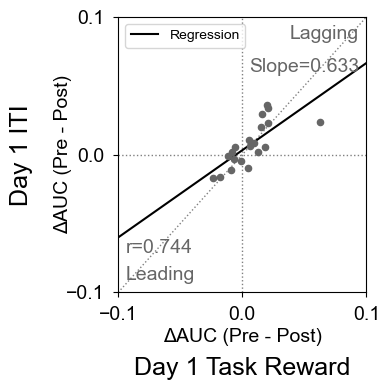

In [552]:
make_scatterplot(compute_mean_dAUC(bootstats_day1_reward)[loc_uniquepair], 
                 compute_mean_dAUC(bootstats_day1_iti)[loc_uniquepair], 
                 "Day 1 Task Reward", "Day 1 ITI", show_slope=True, show_corr=True, savefig_path=replay_figure_folder+"Day1_TaskReward_vs_Day1_ITI_scatter.svg")

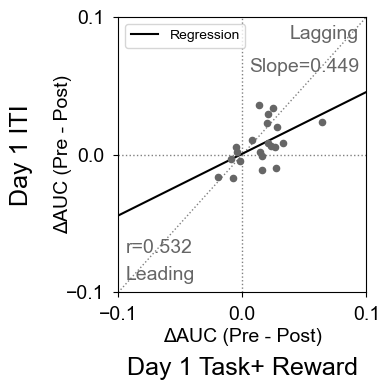

In [554]:
make_scatterplot(compute_mean_dAUC(bootstats_day1_reward_plus)[loc_uniquepair], 
                 compute_mean_dAUC(bootstats_day1_iti)[loc_uniquepair], 
                 "Day 1 Task+ Reward", "Day 1 ITI", show_slope=True, show_corr=True, savefig_path=replay_figure_folder+"Day1_TaskPlusReward_vs_Day1_ITI_scatter.svg")

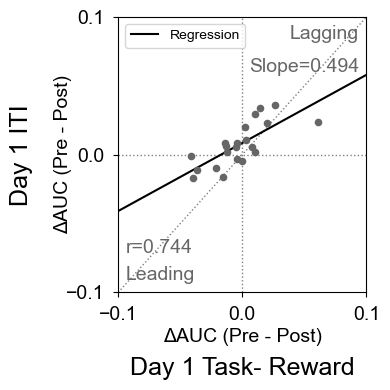

In [555]:
make_scatterplot(compute_mean_dAUC(bootstats_day1_reward_minus)[loc_uniquepair], 
                 compute_mean_dAUC(bootstats_day1_iti)[loc_uniquepair], 
                 "Day 1 Task- Reward", "Day 1 ITI", show_slope=True, show_corr=True, savefig_path=replay_figure_folder+"Day1_TaskMinusReward_vs_Day1_ITI_scatter.svg")

## Heatmaps

In [567]:
from pathlib import Path

DAY_SPECS_REWARD: List[Dict[str, object]] = [
    dict(
        key="first_day", label="first day",
        cs=["day0_task_xcorr_bootstats_reward.npy"],
        csplus=["day0_task_xcorr_bootstats_reward_plus.npy"],
        csminus=["day0_task_xcorr_bootstats_reward_minus.npy"],
    ),
    dict(
        key="second_day_of_learning", label="second day of learning",
        cs=["day1_task_xcorr_bootstats_reward.npy"],
        csplus=["day1_task_xcorr_bootstats_reward_plus.npy"],
        csminus=["day1_task_xcorr_bootstats_reward_minus.npy"],
    ),
    dict(
        key="third_day_of_learning", label="third day of learning",
        cs=["day2_task_xcorr_bootstats_reward.npy"],
        csplus=["day2_task_xcorr_bootstats_reward_plus.npy"],
        csminus=["day2_task_xcorr_bootstats_reward_minus.npy"],
    ),
    dict(
        key="last_day", label="last day",
        # accept either spelling
        cs=["day4_task_xcorr_bootstats_reward.npy"],
        csplus=["day4_task_xcorr_bootstats_reward_plus.npy"],
        csminus=["day4_task_xcorr_bootstats_reward_minus.npy"],
    ),
    dict(
        key="trained_longitudinal", label="trained (longitudinal)",
        cs=["day5_task_xcorr_bootstats_reward.npy"],
        csplus=["day5_task_xcorr_bootstats_reward_plus.npy"],
        csminus=["day5_task_xcorr_bootstats_reward_minus.npy"],
    ),
    dict(
        key="DBE", label="Day Before Extinction",
        cs=["day6_task_xcorr_bootstats_reward.npy"],
        csplus=["day6_task_xcorr_bootstats_reward_plus.npy"],
        csminus=["day6_task_xcorr_bootstats_reward_minus.npy"],
    ),
    dict(
        key="D1EXT", label="Day 1 Extinction",
        cs=["day7_task_xcorr_bootstats_reward.npy"],
        csplus=["day7_task_xcorr_bootstats_reward_plus.npy"],
        csminus=["day7_task_xcorr_bootstats_reward_minus.npy"],
    ),
    dict(
        key="LDEXT", label="Last Day Extinction",
        cs=["day8_task_xcorr_bootstats_reward.npy"],
        csplus=["day8_task_xcorr_bootstats_reward_plus.npy"],
        csminus=["day8_task_xcorr_bootstats_reward_minus.npy"],
    ),
]

# ---- Load data in order ----
reward_series: List[Optional[np.ndarray]] = []
rewardplus_series: List[Optional[np.ndarray]] = []
rewardminus_series: List[Optional[np.ndarray]] = []
day_labels_reward:  List[str] = []
used_paths_reward:  List[Dict[str, Optional[str]]] = []

BASE = Path("/Users/lukepemberton/Desktop/OFC_Backup/Task_samples/")

def _load_first_existing(paths: List[str]) -> Tuple[Optional[np.ndarray], Optional[str]]:
    """Try paths in order return (array, used_path) or (None, None) if none exist."""
    BASE="/Users/lukepemberton/Desktop/OFC_Backup/Task_samples/"
    for p in paths:
        f = BASE / Path(p)
        if f.exists():
            return np.load(f, allow_pickle=True), str(f)
        else:
            raise ValueError(str(p) + " is not the right filename")
    return None, None


for spec in DAY_SPECS_REWARD:
    reward_arr, reward_path = _load_first_existing(spec["cs"])  # type: ignore[arg-type]
    rewardplus_arr, rewardplus_path = _load_first_existing(spec["csplus"])  # type: ignore[arg-type]
    rewardminus_arr, rewardminus_path = _load_first_existing(spec["csminus"])  # type: ignore[arg-type]
    reward_series.append(reward_arr)
    rewardplus_series.append(rewardplus_arr)
    rewardminus_series.append(rewardminus_arr)
    day_labels_reward.append(spec["label"])  # type: ignore[index]
    print(spec["label"])
    used_paths_reward.append({"key": spec["key"], 
                       "reward_path": reward_path,
                       "rewardplus_path": rewardplus_path, 
                       "rewardminus_path": rewardminus_path})  # type: ignore[index]

first day
second day of learning
third day of learning
last day
trained (longitudinal)
Day Before Extinction
Day 1 Extinction
Last Day Extinction


In [571]:
# Matrix order: [Day1 Task CS+, Day1 ITI CS+, Day1 Task CS-, Day1 ITI CS-, Day2 Task CS+, ...]
datasets_reward = []
for i, lbl in enumerate(day_labels_reward):
    datasets_reward += [
        (f"{lbl} Reward CS+", reward_series[i]),
        (f"{lbl} Reward CS+", rewardplus_series[i]),
        (f"{lbl} Reward CS-", rewardminus_series[i]),
        (f"{lbl} ITI", iti_series[i])
    ]
names_reward = [n for n, _ in datasets_reward]
print(names_reward)
N = len(datasets_reward)
print(N, " datasets")
print()

dauc_samples_reward = [compute_samples_dAUC(arr) if arr is not None else None for _, arr in datasets_reward]
dauc_means_reward   = [compute_mean_dAUC(arr)   if arr is not None else None for _, arr in datasets_reward]

ci_slope_reward = np.full((3, N, N), np.nan)  # [mean, lo2.5, hi97.5]
ci_r_reward     = np.full((3, N, N), np.nan)

for i in range(N):
    for j in range(N):
        start = time_counter.time()
        
        di_reward, dj_reward = dauc_samples_reward[i], dauc_samples_reward[j]
        if di_reward is None or dj_reward is None:
            raise ValueError("Missing data")

        n_boot = min(di_reward.shape[0], dj_reward.shape[0])
        samps_slope_reward = np.full(n_boot, np.nan)
        samps_r_reward     = np.full(n_boot, np.nan)

        nan_samples_count = 0
        for xi in range(n_boot):
            x = di_reward[xi, loc_uniquepair].flatten()
            y = dj_reward[xi, loc_uniquepair].flatten()

            if ~np.isnan(x).any() and ~np.isnan(y).any():
                a, b = np.polyfit(x, y, 1)
                samps_slope_reward[xi] = a
                samps_r_reward[xi]     = stats.pearsonr(x, y).statistic
            else:
                nan_samples_count += 1
        print("counted ", nan_samples_count, " nans")

        m_s = np.nanmean(samps_slope_reward) lo_s, hi_s = np.nanpercentile(samps_slope_reward, [2.5, 97.5])
        m_r = np.nanmean(samps_r_reward)     lo_r, hi_r = np.nanpercentile(samps_r_reward,     [2.5, 97.5])

        xm = dauc_means_reward[i][loc_uniquepair] ym = dauc_means_reward[j][loc_uniquepair]

        a_mean = np.polyfit(xm, ym, 1)[0]
        r_mean = stats.pearsonr(xm, ym).statistic

        ndecimal = 5
        if np.isfinite(m_s): 
            assert np.round(lo_s, decimals=ndecimal) <= np.round(m_s, decimals=ndecimal) <= np.round(hi_s, decimals=ndecimal), f"mean slope outside CI @ ({names_reward[i]} vs {names_reward[j]}), values=({np.round(lo_s, decimals=ndecimal)},{np.round(m_s, decimals=ndecimal)},{np.round(hi_s, decimals=ndecimal)})"
        if np.isfinite(a_mean): 
            assert np.round(lo_s, decimals=ndecimal) <= np.round(a_mean, decimals=ndecimal) <= np.round(hi_s, decimals=ndecimal), f"avg-of-boot slope outside CI @ ({names_reward[i]} vs {names_reward[j]}), values=({np.round(lo_s, decimals=ndecimal)},{np.round(a_mean, decimals=ndecimal)},{np.round(hi_s, decimals=ndecimal)})"
        if np.isfinite(m_r): 
            assert np.round(lo_r, decimals=ndecimal) <= np.round(m_r, decimals=ndecimal) <= np.round(hi_r, decimals=ndecimal), f"mean r outside CI @ ({names_reward[i]} vs {names_reward[j]}), values=({np.round(lo_r, decimals=ndecimal)},{np.round(m_r, decimals=ndecimal)},{np.round(hi_r, decimals=ndecimal)})"
        if np.isfinite(r_mean): 
            assert np.round(lo_r, decimals=ndecimal) <= np.round(r_mean, decimals=ndecimal) <= np.round(hi_r, decimals=ndecimal), f"avg-of-boot r outside CI @ ({names_reward[i]} vs {names_reward[j]}), values=({np.round(lo_r, decimals=ndecimal)},{np.round(r_mean, decimals=ndecimal)},{np.round(hi_r, decimals=ndecimal)})"

        ci_slope_reward[:, i, j] = [m_s, lo_s, hi_s]
        ci_r_reward[:, i, j]     = [m_r, lo_r, hi_r]

        stop = time_counter.time()
        print(stop - start)

# Outputs:
# - names: dataset labels in matrix order
# - ci_slope[0..2], ci_r[0..2] => (N x N) mean / 2.5th / 97.5th for slope and Pearson r


['first day Reward CS+', 'first day Reward CS+', 'first day Reward CS-', 'first day ITI', 'second day of learning Reward CS+', 'second day of learning Reward CS+', 'second day of learning Reward CS-', 'second day of learning ITI', 'third day of learning Reward CS+', 'third day of learning Reward CS+', 'third day of learning Reward CS-', 'third day of learning ITI', 'last day Reward CS+', 'last day Reward CS+', 'last day Reward CS-', 'last day ITI', 'trained (longitudinal) Reward CS+', 'trained (longitudinal) Reward CS+', 'trained (longitudinal) Reward CS-', 'trained (longitudinal) ITI', 'Day Before Extinction Reward CS+', 'Day Before Extinction Reward CS+', 'Day Before Extinction Reward CS-', 'Day Before Extinction ITI', 'Day 1 Extinction Reward CS+', 'Day 1 Extinction Reward CS+', 'Day 1 Extinction Reward CS-', 'Day 1 Extinction ITI', 'Last Day Extinction Reward CS+', 'Last Day Extinction Reward CS+', 'Last Day Extinction Reward CS-', 'Last Day Extinction ITI']
32  datasets

counted  

['Day 1 Reward', 'Day 1 Reward +', 'Day 1 Reward -', 'Day 1 ITI', 'Day 2 Reward', 'Day 2 Reward +', 'Day 2 Reward -', 'Day 2 ITI', 'Day 3 Reward', 'Day 3 Reward +', 'Day 3 Reward -', 'Day 3 ITI', 'Last Day Reward', 'Last Day Reward +', 'Last Day Reward -', 'Last Day ITI', 'Trained Reward', 'Trained Reward +', 'Trained Reward -', 'Trained ITI', 'DBE Reward', 'DBE Reward +', 'DBE Reward -', 'DBE ITI', 'Last Day Ext. Reward', 'Last Day Ext. Reward +', 'Last Day Ext. Reward -', 'Last Day Ext. ITI']


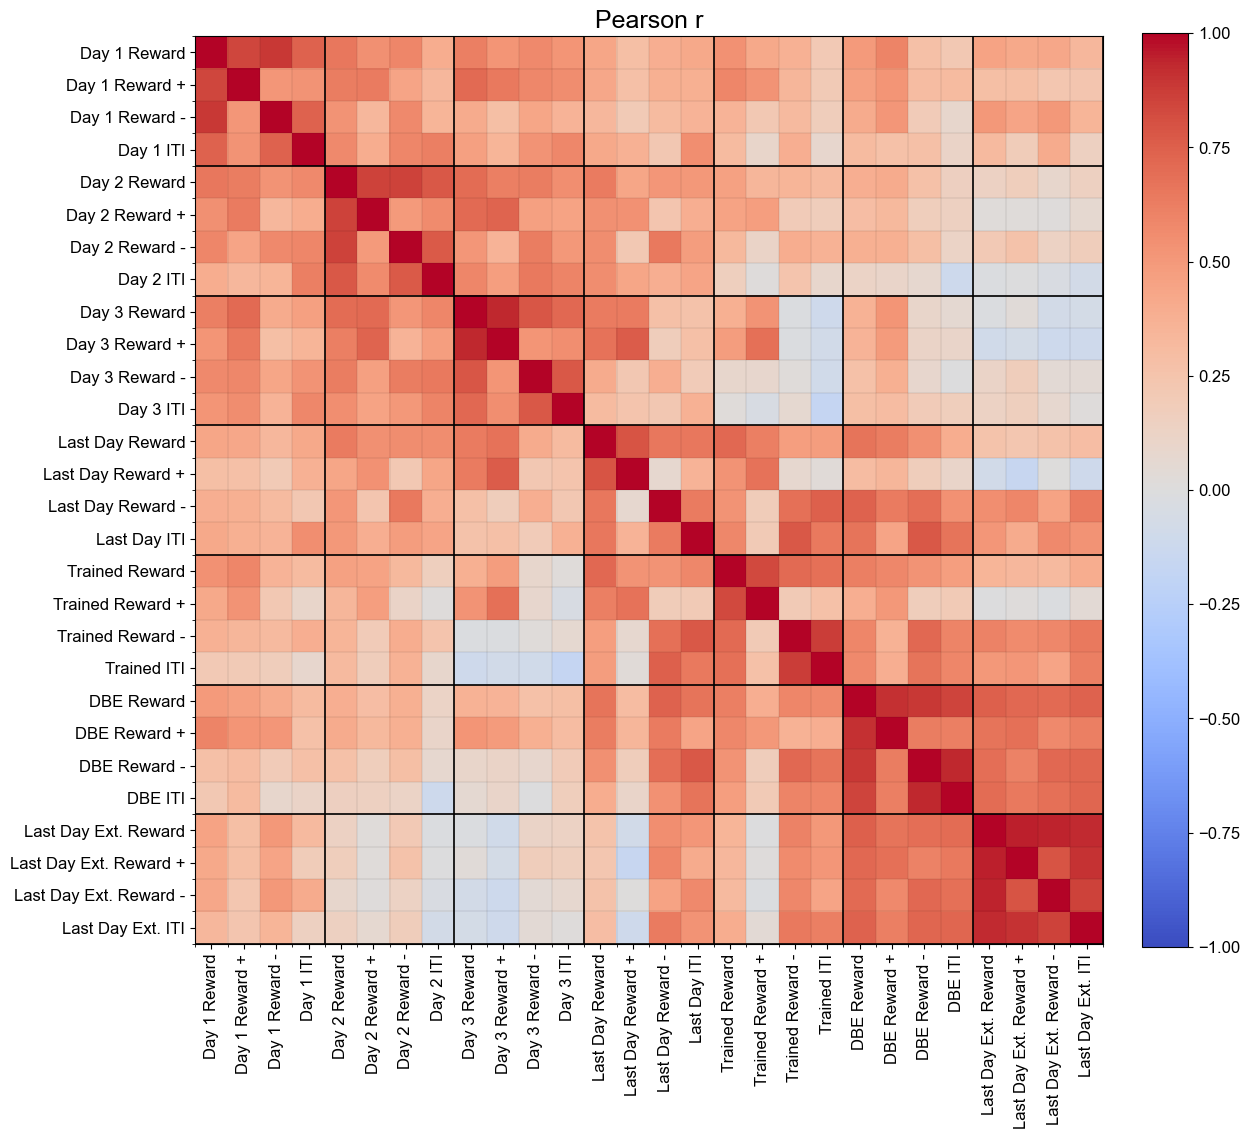

In [579]:
session_labels = ['Day 1', 'Day 2', 'Day 3', 'Last Day', 'Trained', 'DBE', 'Last Day Ext.']
trialtype_periods = ['Reward', 'Reward +', 'Reward -', 'ITI']

labels_ = [day + ' ' + trialtypeperiod for day in session_labels for trialtypeperiod in trialtype_periods]
print(labels_)

def make_heatmap_(M, title=None, title_fs=18, tick_fs=12, labels_=labels_,
                  cmap='coolwarm', vmin=-1, vmax=1, savepath=None, grid_step=4):
    n = len(labels_)
    side = max(6, min(0.45 * n, 18))

    fig, ax = plt.subplots(figsize=(side, side))
    im = ax.imshow(M, interpolation='nearest', aspect='equal', cmap=cmap, vmin=vmin, vmax=vmax)
    if title: ax.set_title(title, fontsize=title_fs)
    ax.set_xticks(np.arange(n)) 
    ax.set_yticks(np.arange(n))
    ax.set_xticklabels(labels_, rotation=90, fontsize=tick_fs)
    ax.set_yticklabels(labels_, fontsize=tick_fs)

    # --- thin grid on every cell ---
    ax.set_xticks(np.arange(-0.5, n, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, n, 1), minor=True)
    ax.grid(which='minor', linestyle='-', linewidth=0.3, color='k', alpha=0.25)

    # --- thick lines every `grid_step` cells (set to 4 for every fourth) ---
    if grid_step and grid_step > 1:
        edges = np.arange(-0.5, n + 0.5, grid_step)
        for e in edges:
            ax.axhline(e, color='k', linewidth=1.2, zorder=3)
            ax.axvline(e, color='k', linewidth=1.2, zorder=3)

    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04).ax.tick_params(labelsize=tick_fs)
    fig.tight_layout()
    if savepath:
        fig.savefig(savepath, format="svg", bbox_inches="tight")
    plt.show()
    plt.close(fig)


indxs = list(range(32))
del indxs[24:28]
make_heatmap_(ci_r_reward[0, ...][indxs,:][:,indxs], title="Pearson r", vmin=-1, vmax=1, savepath=replay_figure_folder+"pearsonr_heatmap_reward.svg")